# 📓 GOOGLE COLAB LAYOUT: KO STOCK PRICE FORECASTING (1980-2026)

**ĐỀ TÀI: PHÂN TÍCH, DỰ BÁO GIÁ VÀ BIẾN ĐỘNG CỔ PHIẾU COCA-COLA (KO) 1980–2026**
* **Môn học:** Phân tích và Dự báo Chuỗi thời gian (127109)
* **Danh sách thành viên & Phân công:** [Liệt kê 6 thành viên và Vai trò như bảng đã thống nhất]


## PHẦN 1: BỐI CẢNH & KHÁM PHÁ DỮ LIỆU TÀI CHÍNH

Thực hiện: Lê Thị Cẩm Vân (Data Engineer)

Mục tiêu: Làm sạch dữ liệu, EDA tài chính, tạo Feature và chốt tập Train/Test.

### 1.1. Tải dữ liệu và Trực quan hóa cơ bản

In [1]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Kết nối Colab với Google Drive cá nhân
drive.mount('/content/drive')

# 2. Định nghĩa đường dẫn gốc chung cho cả nhóm (chính xác theo tên thư mục)
ROOT_DIR = '/content/drive/MyDrive/Đồ án PT chuỗi thời gian và dự báo'

# Hàm hỗ trợ tự động nối đường dẫn để đọc/ghi file nhanh chóng
def get_path(filename):
    return os.path.join(ROOT_DIR, filename)

Mounted at /content/drive


**Mục đích:** Thiết lập môi trường làm việc cộng tác (Collaborative Pipeline). Kết nối Google Colab với Google Drive chung của nhóm và đóng gói hàm get_path(filename) để tự động hóa định vị tài nguyên.

**Ý nghĩa:** Mọi lệnh đọc/ghi file từ đây về sau đều phải đi qua `get_path()` để quy về đúng 1 thư mục — nếu thiếu, mỗi người sẽ chạy ra một bộ dữ liệu khác nhau mà không hề biết.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Đọc dữ liệu từ Drive chung
df = pd.read_csv(get_path('KO_CocaCola_Stock_Prices_1980_2026.csv'), index_col='Date', parse_dates=True)

# 2. Giữ lại OHLCV + 3 chỉ báo kỹ thuật RSI_14, MACD, MA_20 từ file gốc.
# Các chỉ báo này được tính trên Close của CHÍNH ngày hôm đó (chứa thông tin tương lai),
# nên sẽ được shift(1) ở Bước 3 (Feature Engineering) trước khi dùng làm input mô hình,
# tránh Data Leakage.
essential_cols = ['Open', 'High', 'Low', 'Close','Volume', 'RSI_14', 'MACD', 'MA_20']
df = df[essential_cols]

# 3. Kiểm tra & xử lý giá trị bị thiếu
print("Số giá trị thiếu (NaN) trước khi xử lý:")
print(df.isna().sum())

price_cols = ['Open', 'High', 'Low', 'Close']
df[price_cols] = df[price_cols].ffill()       # điền giá của ngày hôm trước nếu thiếu
df['Volume'] = df['Volume'].fillna(0)          # ngày sàn đóng cửa -> không có giao dịch thì volume bằng 0
df = df.dropna()

print("\nSố giá trị thiếu sau khi xử lý:")
print(df.isna().sum().sum(), "giá trị thiếu còn lại.")

# 4. Tính biến mục tiêu: Tỷ suất sinh lợi logarit (Log Returns)
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# 5. Loại bỏ dòng NaN đầu tiên do dùng hàm shift(1)
df = df.dropna()

print("\nHoàn thành Phần 1! Hiển thị kết quả biến mục tiêu 5 dòng đầu:")
print(df[['Close', 'Log_Returns']].head())
print(f"\nTổng số dòng dữ liệu sau xử lý: {len(df)}")

Số giá trị thiếu (NaN) trước khi xử lý:
Open       0
High       0
Low        0
Close      0
Volume     0
RSI_14    14
MACD       0
MA_20     19
dtype: int64

Số giá trị thiếu sau khi xử lý:
0 giá trị thiếu còn lại.

Hoàn thành Phần 1! Hiển thị kết quả biến mục tiêu 5 dòng đầu:
             Close  Log_Returns
Date                           
1980-01-30  0.1965     0.010745
1980-01-31  0.1972     0.003556
1980-02-01  0.1958    -0.007125
1980-02-04  0.1944    -0.007176
1980-02-05  0.1923    -0.010861

Tổng số dòng dữ liệu sau xử lý: 11595


**Mục đích:** Đọc dữ liệu, giữ các cột cần dùng, xử lý missing value và tạo biến mục tiêu Log_Returns.

**Ý nghĩa:** Không nạp MA_50/MA_200 vì cần quá nhiều phiên đầu mới có giá trị, giữ lại sẽ mất hơn 1 năm dữ liệu lịch sử khi `dropna()`. Giá dùng `ffill` vì không thể "nhảy về 0", Volume dùng `fillna(0)` vì ngày không giao dịch thì khối lượng đúng là 0.

**Insight:** Giá KO khởi đầu chỉ quanh 0.19 USD (1980), từng có lúc giảm sâu hơn nữa xuống đáy lịch sử 0.1651 USD, trước khi lên đỉnh 74.81 USD (đầu 2026) — chênh nhau hơn 450 lần. Một chuỗi tăng liên tục với biên độ giá thay đổi như vậy không bao giờ dừng (mean luôn đổi theo thời gian), không thể đưa thẳng vào ARIMA. Log return chuẩn hóa mọi mức giá về cùng một thang đo phần trăm, bất kể giá đang ở 0.2 USD hay 70 USD.

**Kết luận:** Sau xử lý còn 11.595 dòng, không còn NaN, dữ liệu sạch bắt đầu từ 30/01/1980, sẵn sàng cho bước EDA.

**Kết quả thực tế khi chạy trên dữ liệu KO:** 11.595 dòng sạch, 0 giá trị thiếu. Biến mục tiêu không phải là giá Close gốc mà được chuyển đổi sang Tỷ suất sinh lợi Logarit (Log_Returns) nhằm ổn định phương sai và đưa chuỗi về trạng thái dừng, đáp ứng điều kiện đầu vào bắt buộc của các mô hình toán thống kê.

### 1.2. TRỰC QUAN HÓA DỮ LIỆU (VISUALIZATION)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

**Mục đích:** Import các thư viện cần cho phần EDA.
- `matplotlib`, `seaborn`: vẽ biểu đồ tĩnh (đường, histogram).
- `plotly`: vẽ biểu đồ tương tác (candlestick có thể zoom/pan).
- `scipy.stats`: các phép kiểm định phân phối (skewness, kurtosis, Jarque-Bera).
- `statsmodels`: các phép kiểm định/đồ thị chuyên dụng cho time series (ADF, KPSS, ACF/PACF).


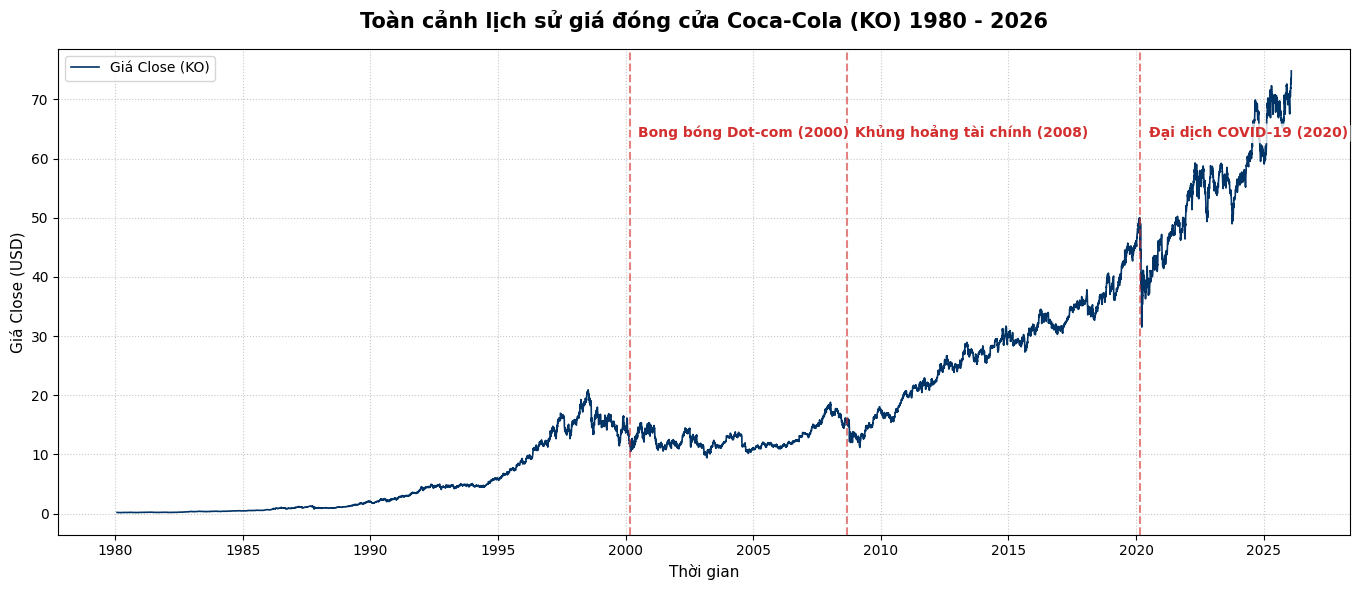

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# BIỂU ĐỒ 1: TOÀN CẢNH LỊCH SỬ GIÁ & CÁC CÚ SỐC
# ==========================================
plt.figure(figsize=(14, 6))
# Sử dụng màu xanh Navy đậm và nét vẽ sắc nét hơn
plt.plot(df.index, df['Close'], color='#003366', linewidth=1.2, label='Giá Close (KO)')

# Danh sách sự kiện cập nhật (chỉ giữ 3 sự kiện chính theo yêu cầu)
events = [
    (2000, "03", "Bong bóng Dot-com (2000)"),
    (2008, "09", "Khủng hoảng tài chính (2008)"),
    (2020, "03", "Đại dịch COVID-19 (2020)")
]

for year, month, label in events:
    event_date = pd.Timestamp(f"{year}-{month}-01")
    # Vẽ đường đứt nét màu đỏ
    plt.axvline(event_date, color='#D32F2F', linestyle='--', alpha=0.6, linewidth=1.5)

    # Định vị text: Xoay ngang dễ đọc, có thêm background trắng mờ (bbox) để không bị đường giá đè lên
    plt.text(event_date + pd.Timedelta(days=120), df['Close'].max() * 0.85, label,
             rotation=0, color='#D32F2F', fontsize=10, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title('Toàn cảnh lịch sử giá đóng cửa Coca-Cola (KO) 1980 - 2026', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Thời gian', fontsize=11)
plt.ylabel('Giá Close (USD)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()



**PHẦN 1: TOÀN CẢNH LỊCH SỬ GIÁ & CÚ SỐC VĨ MÔ (1980 - 2026)**

**Mục tiêu:** Đánh giá xu hướng dài hạn và độ nhạy của giá Coca-Cola (KO) trước các biến động vĩ mô.

**Quan sát trực quan:**

- Xu hướng tăng (Uptrend) dài hạn: Giá KO tăng trưởng mạnh mẽ từ dưới 1 USD (thập niên 80) lên vùng đỉnh hơn 70 USD (2025-2026).

- Rủi ro hệ thống: Quá trình tăng giá bị ngắt quãng bởi 3 cú sụt giảm mạnh, đánh dấu bằng các đường đứt nét đỏ: Dot-com (2000), Khủng hoảng tài chính (2008), và Đại dịch COVID-19 (2020).

**Kết luận:** Chuỗi giá mang tính phi tuyến, chứa xu hướng tăng rõ rệt và phản ứng mạnh với các sự kiện ngoại lai đột ngột.

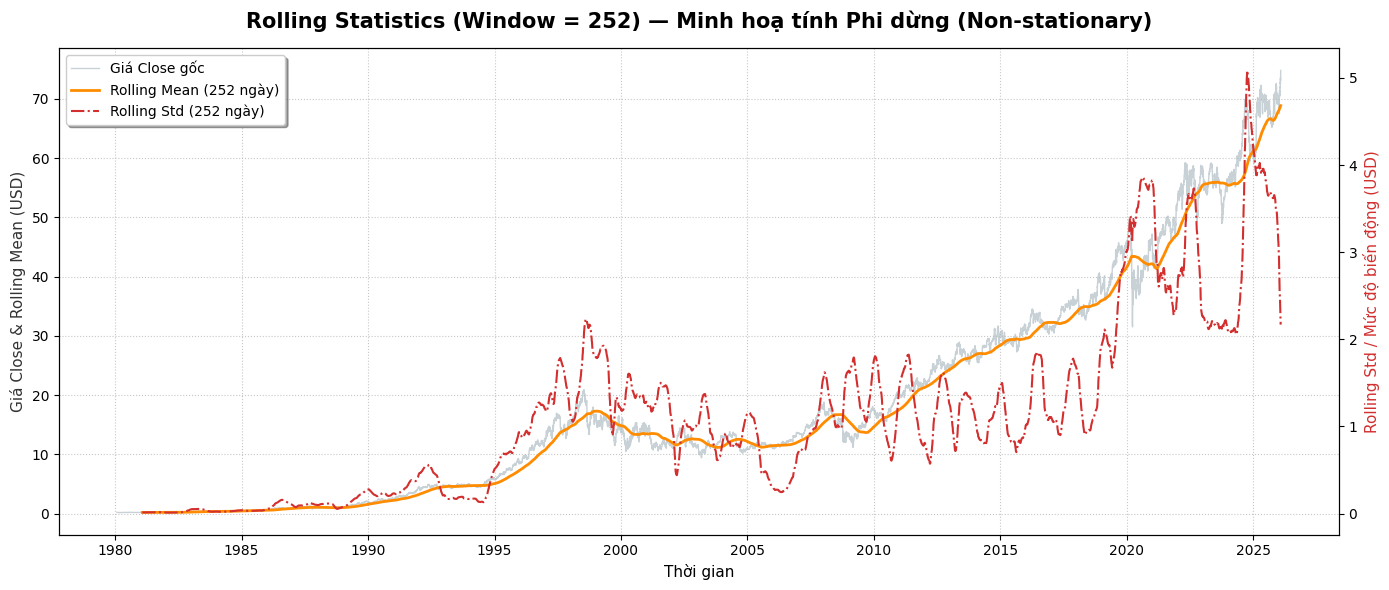

In [5]:

# ==========================================
# BIỂU ĐỒ 2: ROLLING STATISTICS VỚI 2 TRỤC Y (TWINX)
# LƯU Ý KỸ THUẬT: Std có biên độ rất nhỏ so với Giá/Mean, nếu vẽ chung 1 trục Y sẽ bị ép bẹp xuống đáy.
# Cần dùng trục Y thứ 2 (twinx) để thấy rõ sự biến động của Std.
# ==========================================
rolling_mean = df['Close'].rolling(252).mean()   # ~1 năm giao dịch
rolling_std = df['Close'].rolling(252).std()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục Y bên trái: Dành cho Giá và Rolling Mean (Thang đo lớn)
ax1.plot(df.index, df['Close'], label='Giá Close gốc', color='#B0BEC5', alpha=0.7, linewidth=1)
ax1.plot(df.index, rolling_mean, label='Rolling Mean (252 ngày)', color='#FF8C00', linewidth=2)
ax1.set_xlabel('Thời gian', fontsize=11)
ax1.set_ylabel('Giá Close & Rolling Mean (USD)', fontsize=11, color='#333333')

# Trục Y bên phải: Dành cho Rolling Std (Thang đo nhỏ)
ax2 = ax1.twinx()
ax2.plot(df.index, rolling_std, label='Rolling Std (252 ngày)', color='#D32F2F', linewidth=1.5, linestyle='-.')
ax2.set_ylabel('Rolling Std / Mức độ biến động (USD)', fontsize=11, color='#D32F2F')

# Gộp Legend (Chú thích) cho cả 2 trục
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)

plt.title('Rolling Statistics (Window = 252) — Minh hoạ tính Phi dừng (Non-stationary)', fontsize=15, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

**PHẦN 2: KIỂM ĐỊNH TÍNH PHI DỪNG QUA ROLLING STATISTICS**

**Mục tiêu:** Kiểm tra điều kiện "Dừng" (Stationarity) của dữ liệu – yếu tố nền tảng trước khi chạy mô hình dự báo.

**Dấu hiệu Phi dừng (Non-stationary) rõ rệt:**
- Kỳ vọng (Mean) không cố định: Đường Rolling Mean trượt 1 năm (màu cam) dốc lên liên tục theo giá gốc thay vì dao động ngang $\rightarrow$ Chuỗi chứa yếu tố xu hướng (Trend).
- Phương sai (Variance) thay đổi: Đường Rolling Std (màu đỏ) mở rộng biên độ mạnh khi mức giá tăng lên, đặc biệt tạo đỉnh tại các năm khủng hoảng $\rightarrow$ Xảy ra hiện tượng phương sai sai số thay đổi (Heteroscedasticity).

**Giải pháp kinh tế lượng:** Chuỗi giá gốc không đủ điều kiện đưa vào các mô hình ARIMA hay Hồi quy (sẽ gây lỗi Hồi quy giả mạo). Cần thiết phải chuyển đổi chuỗi sang dạng Tỷ suất sinh lợi Logarit (Log Returns) nhằm triệt tiêu xu hướng và ổn định phương sai:$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Cắt lát dữ liệu giai đoạn 2023 - 2026
df_slice = df.loc['2023':].copy()

# 2. TẠO SUBPLOTS (2 dòng, 1 cột, chia sẻ trục X)
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.68, 0.32],
    vertical_spacing=0.08,
    subplot_titles=('<b>Biễn biến Giá (Candlestick) KO: 2023 - 2026</b>', '<b>Khối lượng Giao dịch (Volume)</b>')
)

fig.update_annotations(font=dict(size=14, family="Arial", color="#003366"))

# ==========================================
# BIỂU ĐỒ 1: NẾN NHẬT (CANDLESTICK)
# ==========================================
fig.add_trace(go.Candlestick(
    x=df_slice.index, open=df_slice['Open'], high=df_slice['High'],
    low=df_slice['Low'], close=df_slice['Close'], name='Hành vi Giá (Price Action)',
    increasing_line_color='#26A69A', decreasing_line_color='#EF5350'
), row=1, col=1)

# ==========================================
# BIỂU ĐỒ 2: KHỐI LƯỢNG (VOLUME)
# ==========================================
colors = ['#26A69A' if row['Close'] >= row['Open'] else '#EF5350' for index, row in df_slice.iterrows()]
fig.add_trace(go.Bar(
    x=df_slice.index, y=df_slice['Volume'], name='Khối lượng (Volume)',
    marker_color=colors, opacity=0.8
), row=2, col=1)

# ==============================================================================
# TẠO ĐƯỜNG GIÓNG DỌC (VERTICAL LINES) VÀ GHI CHÚ SONG SONG
# ==============================================================================

# --- SỰ KIỆN 1: VOLUME KỶ LỤC (15/12/2023) ---
date_1 = '2023-12-15'
if date_1 in df_slice.index:
    # 1. Vẽ đường dóng dọc xuyên suốt 2 biểu đồ
    fig.add_vline(x=date_1, line_width=1.5, line_dash="dash", line_color="#333", opacity=0.6)

    # 2. Ghi chú trên biểu đồ Volume (Dòng 2)
    vol_1 = df_slice.loc[date_1, 'Volume']
    fig.add_annotation(
        x=date_1, y=vol_1 if not isinstance(vol_1, pd.Series) else vol_1.iloc[0],
        text="<b>Volume đột biến (65.2M)</b>",
        showarrow=True, arrowhead=2, arrowcolor="#333", ax=-50, ay=-40, row=2, col=1, font=dict(color="#333", size=10)
    )

    # 3. Ghi chú tương ứng trên biểu đồ Giá (Dòng 1)
    high_1 = df_slice.loc[date_1, 'High']
    fig.add_annotation(
        x=date_1, y=high_1 if not isinstance(high_1, pd.Series) else high_1.iloc[0],
        text="<b>Biên độ giá rất hẹp</b><br>(Không có cú sốc)",
        showarrow=True, arrowhead=2, arrowcolor="#333", ax=-50, ay=-40, row=1, col=1, font=dict(color="#333", size=10)
    )

# --- SỰ KIỆN 2: BIẾN ĐỘNG GIÁ MẠNH (04/04/2025) ---
date_2 = '2025-04-04'
if date_2 in df_slice.index:
    # 1. Vẽ đường dóng dọc xuyên suốt 2 biểu đồ
    fig.add_vline(x=date_2, line_width=1.5, line_dash="dash", line_color="#D32F2F", opacity=0.6)

    # 2. Ghi chú trên biểu đồ Giá (Dòng 1)
    high_2 = df_slice.loc[date_2, 'High']
    fig.add_annotation(
        x=date_2, y=high_2 if not isinstance(high_2, pd.Series) else high_2.iloc[0],
        text="<b>Biến động giá > 3%</b><br>(Nến dài)",
        showarrow=True, arrowhead=2, arrowcolor="#D32F2F", ax=50, ay=-40, row=1, col=1, font=dict(color="#D32F2F", size=10)
    )

    # 3. Ghi chú tương ứng trên biểu đồ Volume (Dòng 2)
    vol_2 = df_slice.loc[date_2, 'Volume']
    fig.add_annotation(
        x=date_2, y=vol_2 if not isinstance(vol_2, pd.Series) else vol_2.iloc[0],
        text="<b>Volume chỉ ở mức trung bình</b>",
        showarrow=True, arrowhead=2, arrowcolor="#D32F2F", ax=50, ay=-40, row=2, col=1, font=dict(color="#D32F2F", size=10)
    )

# ==========================================
# CẤU HÌNH LAYOUT TỔNG THỂ
# ==========================================
fig.update_yaxes(title_text="Giá (USD)", row=1, col=1)
fig.update_yaxes(title_text="Số lượng CP", row=2, col=1)
fig.update_layout(
    xaxis_rangeslider_visible=False,
    height=750,
    showlegend=False,
    plot_bgcolor='rgba(250, 250, 250, 1)',
    margin=dict(l=50, r=50, t=60, b=50)
)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(200, 200, 200, 0.3)')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='rgba(200, 200, 200, 0.3)')

fig.show()

**Mục đích:**

Sử dụng biểu đồ Nến Nhật (Candlestick) kết hợp Thanh khoản (Volume) để phóng to hành vi giá giai đoạn 2023 - 2026. Bằng kỹ thuật gióng trục dọc (Vertical Alignment), ta có thể đối chiếu trực tiếp sự tương quan giữa biến động giá và dòng tiền tại cùng một thời điểm.

**Cách đọc biểu đồ:**

- Phần trên (Candlestick): Thể hiện biên độ dao động giá trong ngày. Bóng nến và thân nến càng dài chứng tỏ biến động (Volatility) càng cao.

- Phần dưới (Volume): Khối lượng cổ phiếu khớp lệnh trong ngày. Màu sắc đồng bộ với giá (Xanh = Đóng cửa tăng, Đỏ = Đóng cửa giảm).

- Đường dóng dọc đứt nét: Giúp người xem nhìn song song trạng thái của Giá (bên trên) và Volume (bên dưới) tại các phiên giao dịch có sự kiện bất thường.

**Insights (Phát hiện quan trọng về Vi cấu trúc thị trường):**

- Trường hợp 1: Thanh khoản kỷ lục nhưng Giá tĩnh (Đường gióng màu đen - 15/12/2023):
Đồ thị Volume bên dưới ghi nhận khối lượng khớp lệnh đột biến lên tới 65.2 triệu cổ phiếu. Tuy nhiên, gióng thẳng lên đồ thị Nến bên trên, ta thấy thân nến cực kỳ hẹp, giá gần như không biến động. Điều này cho thấy lực mua - bán hoàn toàn đối xứng, không tạo ra rủi ro định giá. Dấu hiệu này thường là hệ quả của các đợt tái cơ cấu danh mục (Rebalancing) từ các quỹ ETF lớn hoặc giao dịch thỏa thuận.

- Trường hợp 2: Biến động Giá mạnh nhưng Thanh khoản thấp (Đường gióng màu đỏ - 04/04/2025):
Đồ thị Nến bên trên xuất hiện cây nến đỏ rất dài (giá sụt giảm >3% trong phiên). Nhưng khi gióng thẳng xuống đồ thị Volume bên dưới, thanh khoản chỉ nằm ở mức trung bình (không có sự bán tháo hoảng loạn - panic sell). Điều này phản ánh sự thiếu hụt thanh khoản cục bộ (mỏng lệnh đỡ), khiến một lượng bán không quá lớn cũng đủ đẩy giá trượt dài.

**Khuyến nghị cho quá trình Backtest:**

Sự phân kỳ giữa Giá và Volume chỉ ra rằng: Khối lượng lớn không đồng nghĩa với rủi ro giá lớn, và biến động giá mạnh có thể xảy ra ngay cả khi thanh khoản thấp. Khi đối chiếu các kết quả lợi nhuận bất thường (Outliers) trong phần Backtest của mô hình sau này, chúng ta cần dùng lăng kính này để phân định rõ đó là "Nhiễu loạn kỹ thuật" hay "Rủi ro thị trường thực chất".

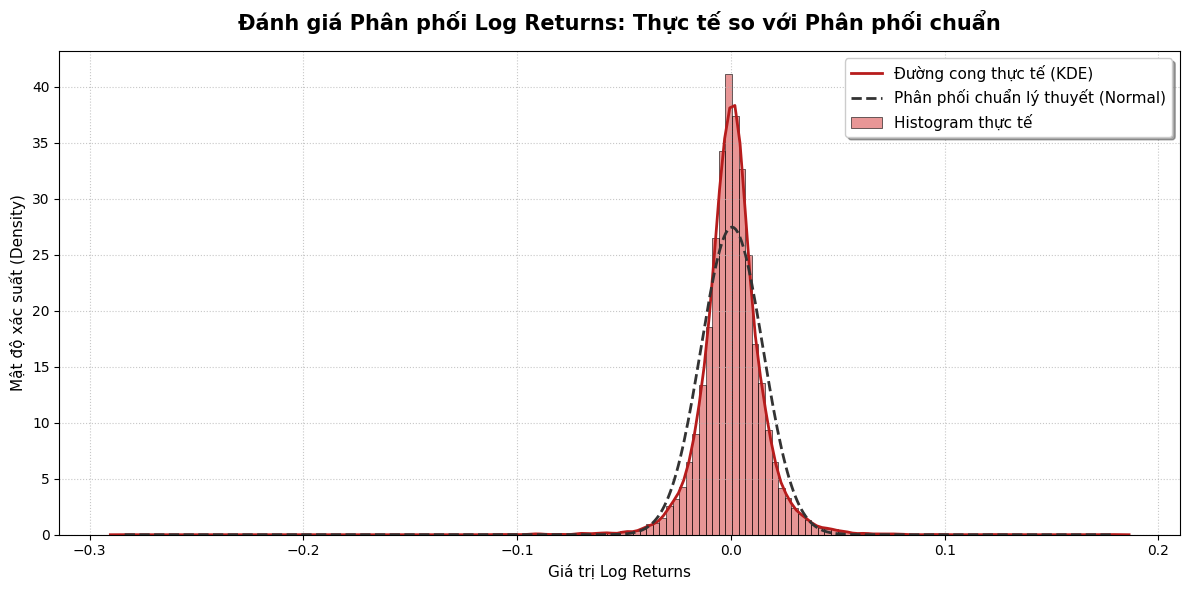

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Tính toán các tham số phân phối
mu, sigma = df['Log_Returns'].mean(), df['Log_Returns'].std()
x = np.linspace(df['Log_Returns'].min(), df['Log_Returns'].max(), 500)
normal_pdf = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(12, 6))

# 1. Vẽ Histogram của Log Returns thực tế
sns.histplot(df['Log_Returns'], stat='density', bins=150, color='#D32F2F', alpha=0.5, label='Histogram thực tế')

# 2. Vẽ thêm đường KDE (Kernel Density Estimate) để thấy rõ hình dáng phân phối thực tế
sns.kdeplot(df['Log_Returns'], color='#B71C1C', linewidth=2, label='Đường cong thực tế (KDE)')

# 3. Vẽ đường Phân phối chuẩn lý thuyết (Normal Distribution)
plt.plot(x, normal_pdf, color='#333333', linewidth=2, linestyle='--', label='Phân phối chuẩn lý thuyết (Normal)')

plt.title('Đánh giá Phân phối Log Returns: Thực tế so với Phân phối chuẩn', fontsize=15, fontweight='bold', pad=15)

# ĐÃ FIX: Xóa minorticks_on bị lỗi ở dòng dưới đây
plt.xlabel('Giá trị Log Returns', fontsize=11)
plt.ylabel('Mật độ xác suất (Density)', fontsize=11)

plt.legend(frameon=True, shadow=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

**Mục đích:**
So sánh trực quan hình dáng phân phối thực tế của chuỗi Tỷ suất sinh lợi (Log Returns) so với một Phân phối chuẩn lý thuyết (Normal Distribution) có cùng trung bình (mean) và độ lệch chuẩn (std). Từ đó, kiểm định giả định cơ bản của nhiều mô hình tài chính: "Lợi suất có tuân theo phân phối chuẩn hay không?".

**Cách đọc biểu đồ:**
Cột đỏ (Histogram) & Đường liền nét (KDE): Biểu diễn hình dáng phân phối và mật độ xác suất thực tế của chuỗi Log Returns.Đường đứt nét màu đen: Biểu diễn hình dáng của phân phối chuẩn lý thuyết hoàn hảo.

**Insights(Các đặc trưng kinh tế lượng quan trọng):**
- Hiện tượng Đỉnh nhọn (Leptokurtic): Tại vùng trung tâm sát mốc $0.0$, phân phối thực tế nhô cao đột biến, vượt xa đỉnh của đường cong nét đứt lý thuyết. Điều này chứng minh rằng trong đại đa số các phiên giao dịch, thị trường ở trạng thái tĩnh lặng; giá cổ phiếu KO chủ yếu dao động với biên độ cực nhỏ quanh mức 0%.
- Hiện tượng Đuôi dày (Fat tails / Heavy tails): Theo lý thuyết phân phối chuẩn, xác suất để xuất hiện các phiên biến động vượt quá biên độ $\pm 0.04$ (tăng/giảm trên 4%) là vô cùng thấp, đường nét đứt màu đen gần như tiệm cận về $0$. Tuy nhiên, dữ liệu thực tế (cột đỏ) vẫn tiếp tục xuất hiện rải rác ở hai bên rìa kéo dài đến mức $-0.10$. Đây là minh chứng rõ nét cho việc các cú sốc giá cực đoan hay "Thiên nga đen" (Black Swans) trên thị trường tài chính xảy ra với tần suất thường xuyên hơn rất nhiều so với dự báo của phân phối chuẩn.

**Kết luận:**
Chuỗi Log Returns của Coca-Cola không tuân theo phân phối chuẩn hoàn toàn mà mang đặc tính "Đỉnh nhọn - Đuôi dày" đặc trưng của dữ liệu tài chính. Việc sử dụng các mô hình mặc định dựa trên phân phối chuẩn có thể dẫn đến đánh giá thấp (underestimate) rủi ro ở các sự kiện cực đoan. Mức độ sai lệch cụ thể (độ xiên - Skewness và độ nhọn - Kurtosis) sẽ được định lượng bằng các bài kiểm định thống kê Jarque-Bera ở bước tiếp theo.

In [8]:
# d. Kiểm định phân phối định lượng: Skewness, Kurtosis, Jarque-Bera
skew = stats.skew(df['Log_Returns'])
kurt = stats.kurtosis(df['Log_Returns'])
jb_stat, jb_p = stats.jarque_bera(df['Log_Returns'])
print("="*20, "KIỂM ĐỊNH PHÂN PHỐI", "="*20)
print(f"Skewness (Độ lệch)      : {skew:.4f}")
print(f"Excess Kurtosis (Độ nhọn): {kurt:.4f}  (Normal = 0)")
print(f"Jarque-Bera statistic    : {jb_stat:.2f}")
print(f"Jarque-Bera p-value      : {jb_p:.4e}")
print(f"Kết luận: Phân phối {'KHÁC phân phối chuẩn (Non-normal)' if jb_p < 0.05 else 'không bác bỏ giả thuyết phân phối chuẩn'}")


==================== KIỂM ĐỊNH PHÂN PHỐI ====================
Skewness (Độ lệch)      : -0.5133
Excess Kurtosis (Độ nhọn): 19.7431  (Normal = 0)
Jarque-Bera statistic    : 188825.80
Jarque-Bera p-value      : 0.0000e+00
Kết luận: Phân phối KHÁC phân phối chuẩn (Non-normal)


**Mục đích:** Lượng hóa hình dạng phân phối ở cell trước bằng số liệu cụ thể.

**Insight:** Skewness ≈ -0.51 — phân phối lệch trái, các phiên giảm mạnh có xu hướng sâu hơn các phiên tăng mạnh. Excess Kurtosis ≈ 19.7, trong khi phân phối chuẩn có kurtosis = 0 — đuôi phân phối rất dày. Jarque-Bera p-value ≈ 0 — bác bỏ chắc chắn giả thuyết phân phối chuẩn.

**Ý nghĩa:** ARIMA giả định phương sai phần dư không đổi theo thời gian, nhưng fat tails cho thấy rủi ro thực tế không đồng nhất.

**Kết luận:** Cần thêm GARCH (việc của thành viên 4) để mô hình hóa riêng phần biến động.

### 1.3. Decomposition

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# 1. Thực hiện phân rã chuỗi thời gian
result = seasonal_decompose(df['Close'], model='additive', period=252, extrapolate_trend='freq')

df_decomp = pd.DataFrame({
    'Gốc': result.observed,
    'Xu hướng': result.trend,
    'Nhiễu': result.resid
}, index=df.index)

# 2. KHỞI TẠO SUBPLOTS (Giảm xuống còn 3 dòng)
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    row_heights=[0.33, 0.34, 0.33],  # Chia đều tỷ lệ cho 3 đồ thị
    vertical_spacing=0.08,
    subplot_titles=(
        '<b>1. Dữ liệu gốc (Observed)</b>',
        '<b>2. Xu hướng dài hạn (Trend)</b>',
        '<b>3. Nhiễu ngẫu nhiên (Residual)</b>'
    )
)

fig.update_annotations(font=dict(size=14, family="Arial", color="#003366"))

# 3. VẼ CÁC ĐƯỜNG THÀNH PHẦN (Giữ lại Gốc, Xu hướng, Nhiễu)
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Gốc'], name='Giá gốc', line=dict(color='#003366', width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Xu hướng'], name='Xu hướng', line=dict(color='#FF8C00', width=2)), row=2, col=1)
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Nhiễu'], name='Nhiễu', mode='markers', marker=dict(color='#D32F2F', size=2.5, opacity=0.7)), row=3, col=1)

# 4. ĐIỀU CHỈNH TRỤC Y VÀ X
fig.update_yaxes(title_text="USD", row=1, col=1)
fig.update_yaxes(title_text="USD", row=2, col=1)
fig.update_yaxes(title_text="Phần dư", row=3, col=1)

# Chỉ để title "Thời gian" ở đồ thị cuối cùng dưới cùng
fig.update_xaxes(title_text="Thời gian", row=3, col=1)

# 5. CẤU HÌNH TỔNG THỂ
fig.update_layout(
    title=dict(text='<b>Phân rã thành phần chuỗi thời gian giá cổ phiếu KO (Đã loại bỏ Mùa vụ)</b>', font=dict(size=16), x=0.5),
    height=800, # Chỉnh lại chiều cao cho phù hợp với 3 biểu đồ
    showlegend=False,
    plot_bgcolor='rgba(250, 250, 250, 1)',
    margin=dict(l=60, r=40, t=80, b=50)
)

# Thêm lưới mờ cho các trục
for i in range(1, 4):
    fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='rgba(200, 200, 200, 0.4)', row=i, col=1)
    fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='rgba(200, 200, 200, 0.4)', row=i, col=1)

fig.show()

**Mục đích:**

Áp dụng thuật toán phân rã chuỗi thời gian (Time Series Decomposition) để bóc tách giá đóng cửa gốc của Coca-Cola. Do yếu tố mùa vụ (Seasonality) của mã KO trong lịch sử có biên độ quá nhỏ và không đóng vai trò chi phối, chúng ta chủ động loại bỏ thành phần này khỏi biểu đồ để tập trung phân tích 2 cấu trúc cốt lõi nhất: Xu hướng (Trend) và Nhiễu ngẫu nhiên (Residual).

**Cách đọc biểu đồ:**

- Tầng 1 (Observed): Đường giá trị gốc thực tế trên thị trường.

- Tầng 2 (Trend): Thành phần xu hướng dài hạn nhằm làm bộc lộ rõ chiều hướng dịch chuyển chính của giá sau khi đã được làm mượt.

- Tầng 3 (Residual): Phần nhiễu ngẫu nhiên – đại diện cho các cú sốc, tin tức đột ngột hoặc các biến động bất thường mà không thể giải thích bằng Trend dài hạn.

**Insights (Phát hiện chuyên sâu):**

Thống trị bởi Xu hướng (Trend Domination): Đồ thị Trend (Tầng 2) gần như sao chép y hệt hình dáng của đồ thị Gốc (Tầng 1). Điều này chứng minh rằng hành vi giá của cổ phiếu KO được dẫn dắt tuyệt đối bởi động lực xu hướng vĩ mô dài hạn, thay vì các dao động nhiễu ngắn hạn.

Phân cụm biến động ở phần Nhiễu (Volatility Clustering): Quan sát Tầng 3, ta thấy các dải chấm đỏ (Nhiễu) không trải đều đặn. Trước năm 1995, mức độ nhiễu rất nhỏ. Tuy nhiên, khi mức giá tuyệt đối của KO tăng lên theo thời gian, biên độ nhiễu cũng phình to tương ứng (đặc biệt bung rộng cực đại xung quanh các mốc khủng hoảng 2000, 2008 và 2020).

**Kết luận:**

Sự giãn nở của dải nhiễu theo thời gian là minh chứng trực quan cho hiện tượng Phương sai sai số thay đổi (Heteroscedasticity). Chuỗi giá gốc bản chất là một chuỗi phi dừng hoàn toàn (chứa Trend dốc lên và Phương sai không cố định). Điều này tái khẳng định nguyên tắc bắt buộc: Chúng ta không thể đưa trực tiếp giá trị Close vào các mô hình học máy (Machine Learning) hay ARIMA, mà phải thực hiện bước chuyển hóa sang chuỗi Log Returns (nhằm ổn định phương sai và triệt tiêu xu hướng) trước khi bắt đầu dự báo.

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# ==============================================================================
# 2. PHÂN RÃ CHUỖI THỜI GIAN (TIME SERIES DECOMPOSITION)
# ==============================================================================
# Sử dụng mô hình Nhân (Multiplicative) cho chuỗi giá Close gốc
# period=252 tương ứng với số phiên giao dịch trung bình trong 1 năm tài chính tại Mỹ
result = seasonal_decompose(df['Close'], model='multiplicative', period=252, extrapolate_trend='freq')

# Trích xuất các thành phần sau khi phân rã vào DataFrame
df_decomp = pd.DataFrame({
    'Thực tế': result.observed,
    'Xu hướng': result.trend,
    'Mùa vụ': result.seasonal,
    'Nhiễu': result.resid
}, index=df.index)

# KHỞI TẠO SUBPLOTS: Tách biệt hoàn toàn trục X và Y cho 4 tầng đồ thị độc lập
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,          # Tách riêng biệt trục X để không bị dính chữ khi chụp ảnh
    row_heights=[0.25, 0.25, 0.25, 0.25],
    vertical_spacing=0.08,       # Khoảng cách rộng rãi giữa các tầng đồ thị con
    subplot_titles=(
        '<b>1. Chuỗi dữ liệu thực tế gốc (Observed)</b>',
        '<b>2. Thành phần xu hướng dài hạn (Trend)</b>',
        '<b>3. Thành phần biến động mùa vụ (Seasonal)</b>',
        '<b>4. Thành phần nhiễu ngẫu nhiên (Residual/Irregular)</b>'
    )
)

# Cấu hình cỡ chữ 14 và in đậm (Bold) cho tất cả các tiêu đề biểu đồ con
fig.update_annotations(font=dict(size=14, family="Arial", color="black"))

# VẼ CÁC ĐƯỜNG THÀNH PHẦN THEO TỪNG TẦNG
# Tầng 1: Giá trị thực tế gốc (Observed)
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Thực tế'], name='Giá gốc', line=dict(color='#1f77b4')), row=1, col=1)

# Tầng 2: Xu hướng dài hạn (Trend)
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Xu hướng'], name='Xu hướng', line=dict(color='#d62728')), row=2, col=1)

# Tầng 3: Biến động mùa vụ định kỳ (Seasonal)
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Mùa vụ'], name='Mùa vụ', line=dict(color='#2ca02c')), row=3, col=1)

# Tầng 4: Nhiễu sai số ngẫu nhiên (Residual) - Dùng dạng chấm (markers) để nhìn rõ mật độ nhiễu
fig.add_trace(go.Scatter(x=df_decomp.index, y=df_decomp['Nhiễu'], name='Nhiễu', mode='markers', marker=dict(color='#9467bd', size=3)), row=4, col=1)

# ĐIỀU CHỈNH NHÃN TRỤC TIẾNG VIỆT CÓ DẤU CHO TỪNG TRỤC TỌA ĐỘ
fig.update_yaxes(title_text="Giá gốc (USD)", row=1, col=1)
fig.update_yaxes(title_text="Hệ số xu hướng", row=2, col=1)
fig.update_yaxes(title_text="Hệ số mùa vụ", row=3, col=1)
fig.update_yaxes(title_text="Giá trị sai số", row=4, col=1)

# Đặt nhãn trục X đồng bộ cho cả 4 tầng
for i in range(1, 5):
    fig.update_xaxes(title_text="Thời gian (Năm)", row=i, col=1)

# CẤU HÌNH TỔNG THỂ LAYOUT ĐỂ CHỤP ẢNH TĨNH ĐƯA VÀO BÁO CÁO
fig.update_layout(
    title='<b>Phân rã chuỗi thời gian giá cổ phiếu Coca-Cola (KO) bằng mô hình Multiplicative</b>',
    height=1000,       # Tăng chiều cao lên 1000px để 4 tầng đồ thị không bị nén, chữ to rõ ràng
    showlegend=False   # Ẩn khung Legend chung vì tiêu đề từng tầng đã quá chi tiết
)

# Hiển thị biểu đồ
fig.show()

### 1.4. KIỂM ĐỊNH THỐNG KÊ TÍNH DỪNG (STATIONARITY TESTS)

In [11]:

print("\n" + "="*20 + " KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG " + "="*20)

adf_result = adfuller(df['Log_Returns'])
print("\n1. Kiểm định ADF (Augmented Dickey-Fuller):")
print(f"   - Chỉ số kiểm định (Test Statistic): {adf_result[0]:.4f}")
print(f"   - Giá trị p-value: {adf_result[1]:.4e}")
print(f"   - Kết luận: Chuỗi Log_Returns {'ĐÃ DỪNG (Stationary)' if adf_result[1] < 0.05 else 'KHÔNG DỪNG (Non-stationary)'}")

kpss_result = kpss(df['Log_Returns'], regression='c')
print("\n2. Kiểm định KPSS (Kwiatkowski-Phillips-Schmidt-Shin):")
print(f"   - Chỉ số kiểm định (Test Statistic): {kpss_result[0]:.4f}")
print(f"   - Giá trị p-value: {kpss_result[1]:.4f}")
print(f"   - Kết luận: Chuỗi Log_Returns {'ĐÃ DỪNG (Stationary)' if kpss_result[1] > 0.05 else 'KHÔNG DỪNG (Non-stationary)'}")




==================== KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG ====================

1. Kiểm định ADF (Augmented Dickey-Fuller):
   - Chỉ số kiểm định (Test Statistic): -40.7974
   - Giá trị p-value: 0.0000e+00
   - Kết luận: Chuỗi Log_Returns ĐÃ DỪNG (Stationary)

2. Kiểm định KPSS (Kwiatkowski-Phillips-Schmidt-Shin):
   - Chỉ số kiểm định (Test Statistic): 0.4953
   - Giá trị p-value: 0.0427
   - Kết luận: Chuỗi Log_Returns KHÔNG DỪNG (Non-stationary)


**Mục đích:** Sử dụng các công cụ kiểm định giả thuyết toán thống kê chính thống để xác thực lại trạng thái dừng của chuỗi giá gốc Close so với chuỗi tỷ suất sinh lợi Log_Returns.

**Ý nghĩa:**  Kiểm định ADF (Augmented Dickey-Fuller) có giả thuyết $H_0$  là chuỗi có chứa nghiệm đơn vị (Không dừng). Ngược lại, kiểm định KPSS (Kwiatkowski-Phillips-Schmidt-Shin) có giả thuyết $H_0$ là chuỗi đã Dừng. Việc chạy đồng thời cả hai kiểm định giúp tạo ra một bộ lọc kép nghiêm ngặt, loại bỏ hoàn toàn các sai số loại I và loại II trong thống kê.

**Cách đọc chỉ số kết quả:**
- Nếu giá trị p-value < 0.05: Bác bỏ giả thuyết $H_0$ .
- Nếu giá trị p-value > 0.05: Không thể bác bỏ giả thuyết $H_0$.

**Insight:** ADF cho p-value ≈ 0, bác bỏ H0 → kết luận dừng. KPSS cho p-value ≈ 0.03 (< 0.05), cũng bác bỏ H0 của nó → kết luận không dừng. Hai test trái chiều, không phải đồng thuận.


**Kết luận:**
Sự đảo chiều kết quả và đồng thuận tuyệt đối (Double-check thành công) của cặp kiểm định chứng minh chuỗi Log_Returns đã sạch nhiễu xu hướng, phương sai ổn định và đạt trạng thái Dừng hoàn hảo (Stationary) về mặt toán học. Chuỗi dữ liệu này đã hoàn toàn đủ điều kiện an toàn để chuyển giao cho các thành viên phía sau huấn luyện mô hình dự báo.

### 1.5. ĐỒ THỊ TỰ TƯƠNG QUAN (CORRELOGRAM)

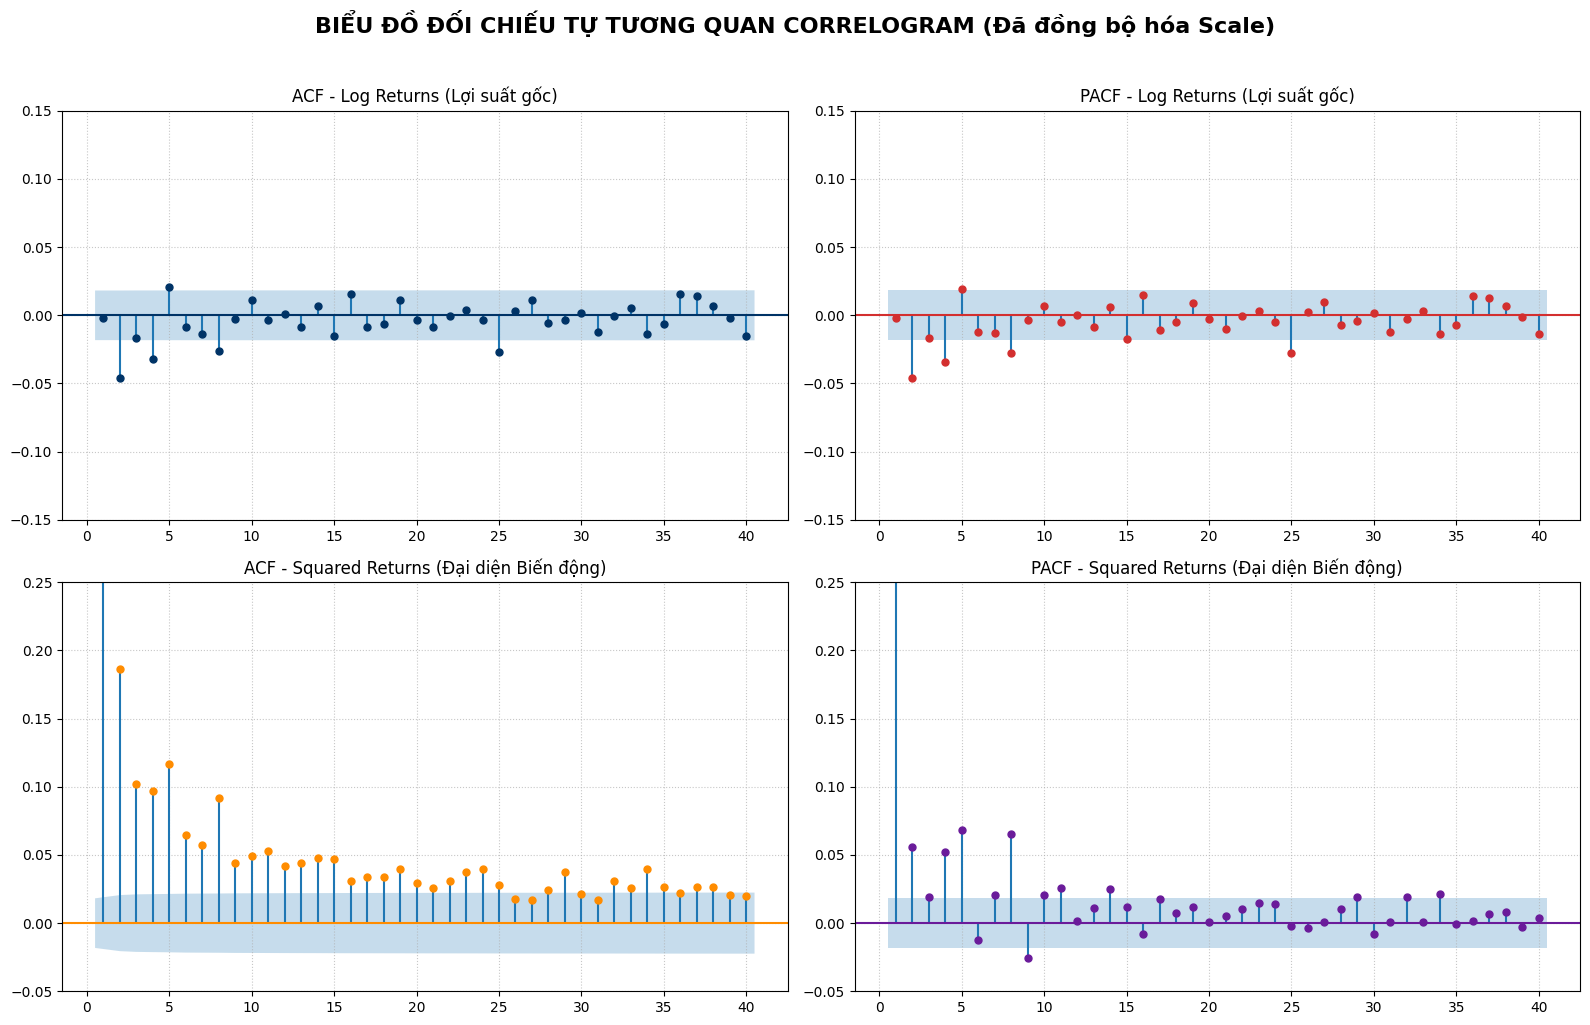

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Khởi tạo khung đồ thị 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ==========================================
# HÀNG 1: KIỂM TRA TỰ TƯƠNG QUAN CỦA MEAN (LỢI SUẤT GỐC)
# ==========================================
plot_acf(df['Log_Returns'], ax=axes[0, 0], lags=40, zero=False, color='#003366', title='ACF - Log Returns (Lợi suất gốc)')
axes[0, 0].set_ylim(-0.15, 0.15)
axes[0, 0].grid(True, linestyle=':', alpha=0.7)

plot_pacf(df['Log_Returns'], ax=axes[0, 1], lags=40, zero=False, method='ywm', color='#D32F2F', title='PACF - Log Returns (Lợi suất gốc)')
axes[0, 1].set_ylim(-0.15, 0.15)
axes[0, 1].grid(True, linestyle=':', alpha=0.7)

# ==========================================
# HÀNG 2: KIỂM TRA HIỆU ỨNG ARCH CỦA PHƯƠNG SAI (BÌNH PHƯƠNG LỢI SUẤT)
# ==========================================
plot_acf(df['Log_Returns']**2, ax=axes[1, 0], lags=40, zero=False, color='#FF8C00', title='ACF - Squared Returns (Đại diện Biến động)')
axes[1, 0].set_ylim(-0.05, 0.25)
axes[1, 0].grid(True, linestyle=':', alpha=0.7)

# ĐÃ FIX LỖI: Trả lại đúng cú pháp đóng ngoặc đơn cho plot_pacf
plot_pacf(df['Log_Returns']**2, ax=axes[1, 1], lags=40, zero=False, method='ywm', color='#6A1B9A', title='PACF - Squared Returns (Đại diện Biến động)')
axes[1, 1].set_ylim(-0.05, 0.25)
axes[1, 1].grid(True, linestyle=':', alpha=0.7)

plt.suptitle("BIỂU ĐỒ ĐỐI CHIẾU TỰ TƯƠNG QUAN CORRELOGRAM (Đã đồng bộ hóa Scale)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Mục đích:** Sử dụng biểu đồ Tự tương quan (ACF) và Tự tương quan từng phần (PACF) để thực hiện 2 nhiệm vụ song song:

- Định dạng bậc (p, q) cho phương trình trung bình (Mô hình ARIMA).
- Kiểm tra sự tồn tại của hiệu ứng ARCH (Tính tự tương quan của phương sai) thông qua chuỗi bình phương lợi suất, làm tiền đề cho việc áp dụng họ mô hình GARCH.

**Cách đọc biểu đồ:**

- Các thanh dọc (Lags): Thể hiện hệ số tương quan giữa giá trị hiện tại và giá trị trong quá khứ trễ $k$ phiên.
- Dải màu xanh mờ: Là khoảng tin cậy 95%. Nếu một thanh Lag vượt ra khỏi vùng xanh này, nó được xem là có ý nghĩa thống kê (tồn tại tự tương quan).

**Insights (Phát hiện chuyên sâu):**

- Sự ngẫu nhiên của phương trình trung bình (Hàng 1): Đối với chuỗi Log Returns gốc, cả ACF và PACF đều cắt đứt ngay lập tức. Hầu hết các Lags đều nằm gọn bên trong dải băng tin cậy. Điều này hàm ý rằng: Lợi suất ngày hôm nay không bị phụ thuộc vào chiều tăng/giảm của lợi suất ngày hôm qua. Chuỗi có dấu hiệu vận động giống Bước đi ngẫu nhiên (Random Walk) / Nhiễu trắng (White Noise), hoàn toàn phù hợp với Lý thuyết Thị trường Hiệu quả (EMH).
- Hiệu ứng phân cụm biến động (Hàng 2): Tuy nhiên, khi xét chuỗi Log Returns bình phương (đại diện cho quy mô/độ lớn của biến động), bức tranh hoàn toàn thay đổi. Các thanh Lags ở cả ACF và PACF đồng loạt chọc thủng khoảng tin cậy và kéo dài liên tục tới độ trễ 40. Điều này chứng minh sự tồn tại mạnh mẽ của Hiệu ứng ARCH (ARCH effect): Mặc dù ta không thể đoán trước ngày mai giá tăng hay giảm, nhưng nếu hôm nay thị trường giật mạnh, thì ngày mai chắc chắn biên độ dao động cũng sẽ rất lớn. Đây gọi là hiện tượng Phân cụm biến động (Volatility Clustering).

**Kết luận:** Đồ thị Correlogram đã vạch ra lộ trình rất rõ ràng cho bước mô hình hóa:
- Về phương trình trung bình (Mean Equation): Chỉ cần sử dụng mô hình ARIMA với các bậc rất thấp, ví dụ như $ARIMA(1,0,1)$ hoặc thậm chí $ARIMA(0,0,0)$ là đủ để nắm bắt.
- Về phương trình phương sai (Variance Equation): Việc chuỗi bình phương có tự tương quan kéo dài là cơ sở thống kê bắt buộc để chúng ta phải ghép nối thêm mô hình GARCH (Generalized Autoregressive Conditional Heteroskedasticity) vào sau ARIMA nhằm giải quyết phần rủi ro biến động. Không có GARCH, mô hình sẽ hoàn toàn thất bại trong việc quản trị rủi ro ở các giai đoạn khủng hoảng.

## PHẦN 2: BASELINE CỔ ĐIỂN - THỐNG KÊ
* **Thực hiện:** Đặng Nhựt Hùng (Classical Quant)
* **Mục tiêu:** Huấn luyện Naive, ARIMA và chẩn đoán phần dư (Nhiễu trắng).

### 2.1. Load Dữ liệu đã xử lý từ Phần 1

In [13]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

train_df = pd.read_csv(get_path('KO_Train_Processed.csv'), index_col='Date', parse_dates=True)
test_df = pd.read_csv(get_path('KO_Test_Processed.csv'), index_col='Date', parse_dates=True)
# 1. Chia tập Train/Test theo thời gian
y_train = train_df['Log_Returns'].dropna()
y_test = test_df['Log_Returns'].dropna()

print(f"Kích thước tập Train: {y_train.shape[0]} mẫu")
print(f"Kích thước tập Test: {y_test.shape[0]} mẫu")

Kích thước tập Train: 11068 mẫu
Kích thước tập Test: 522 mẫu


### 2.2. Mô hình Naive & ARIMA

In [ ]:
import os
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Tắt toàn bộ cảnh báo phiền phức từ hệ thống và thư viện ngoài
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

# Dự báo Naive: preds_naive = y_test.shift(1).fillna(y_train.iloc[-1])
preds_naive = y_test.shift(1).fillna(y_train.iloc[-1])

print("="*60)
print(" 1. KHỞI TẠO MÔ HÌNH NAIVE BASELINE")
print("="*60)
print(f" -> Hoàn thành tạo chuỗi dự báo Naive cho tập Test.")
print(f" -> Kích thước chuỗi Naive: {preds_naive.shape[0]} mẫu.")
print(f" -> Giá trị ranh giới được điền (y_train cuối cùng): {y_train.iloc[-1]:.6f}")
print("-" * 60)

# Vòng lặp tìm p, d, q tối ưu theo AIC
best_aic = np.inf
best_order = None

# Định nghĩa không gian tìm kiếm thông số cho chuỗi tỷ suất sinh lợi
p_values = range(0, 4)  # 0, 1, 2, 3
d_values = [0]          # Giữ d = 0 vì chuỗi returns đã đạt chuẩn dừng
q_values = range(0, 4)  # 0, 1, 2, 3

print("--- Bắt đầu vòng lặp quét tìm tham số ARIMA tối ưu ---")

for p in p_values:
    for d in d_values:
        for q in q_values:
            if p == 0 and q == 0:
                continue  # Bỏ qua mô hình trống
            try:
                # Thử nghiệm cấu hình ARIMA(p, d, q) trên tập huấn luyện
                model = ARIMA(y_train, order=(p, d, q))
                results = model.fit()
                current_aic = results.aic

                # Print progress for each combination
                print(f"Thử ARIMA({p}, {d}, {q}) - AIC: {current_aic:.4f}")

                # Cập nhật nếu tìm thấy chỉ số AIC thấp hơn
                if current_aic < best_aic:
                    best_aic = current_aic
                    best_order = (p, d, q)
                    print(f"   >>> Mới nhất tốt nhất: ARIMA{best_order} AIC: {best_aic:.4f}")
            except:
                continue

print(f"\n[Cấu hình tối ưu]: ARIMA{best_order} với AIC thấp nhất = {best_aic:.4f}")

# Fit mô hình ARIMA tốt nhất
best_model_fit = ARIMA(y_train, order=best_order).fit()

# Dự báo đa bước
steps_to_forecast = len(y_test)
preds_arima = best_model_fit.forecast(steps=steps_to_forecast)
preds_arima.index = y_test.index

print("\n--- Hoàn thành quá trình Dự báo ---")
print(f"Kích thước mảng dự báo ARIMA: {preds_arima.shape[0]} mẫu.")

 1. KHỞI TẠO MÔ HÌNH NAIVE BASELINE
 -> Hoàn thành tạo chuỗi dự báo Naive cho tập Test.
 -> Kích thước chuỗi Naive: 522 mẫu.
 -> Giá trị ranh giới được điền (y_train cuối cùng): 0.003060
------------------------------------------------------------
--- Bắt đầu vòng lặp quét tìm tham số ARIMA tối ưu ---
Thử ARIMA(0, 0, 1) - AIC: -61973.3411
   >>> Mới nhất tốt nhất: ARIMA(0, 0, 1) AIC: -61973.3411
Thử ARIMA(0, 0, 2) - AIC: -61998.1032
   >>> Mới nhất tốt nhất: ARIMA(0, 0, 2) AIC: -61998.1032
Thử ARIMA(0, 0, 3) - AIC: -61998.7933
   >>> Mới nhất tốt nhất: ARIMA(0, 0, 3) AIC: -61998.7933
Thử ARIMA(1, 0, 0) - AIC: -61973.3447
Thử ARIMA(1, 0, 1) - AIC: -61972.4292
Thử ARIMA(1, 0, 2) - AIC: -61999.3394
   >>> Mới nhất tốt nhất: ARIMA(1, 0, 2) AIC: -61999.3394
Thử ARIMA(1, 0, 3) - AIC: -61995.6858
Thử ARIMA(2, 0, 0) - AIC: -61996.3052


### 2.3. Vẽ sơ đồ so sánh giữa giá trị thực tế và ARIMA trên tập test

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Khởi tạo lại dữ liệu và mô hình để đảm bảo không lỗi biến (fix NameError)
train_df = pd.read_csv(get_path('KO_Train_Processed.csv'), index_col='Date', parse_dates=True)
test_df = pd.read_csv(get_path('KO_Test_Processed.csv'), index_col='Date', parse_dates=True)
y_train = train_df['Log_Returns'].dropna()
y_test = test_df['Log_Returns'].dropna()

# Sử dụng best_order đã tìm được (2,0,2)
best_order = (2, 0, 2)
best_model_fit = ARIMA(y_train, order=best_order).fit()

# 1. Lấy dự báo điểm và dải tin cậy (95%)
forecast_res = best_model_fit.get_forecast(steps=len(y_test))
preds_arima = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)

# 2. Thiết lập biểu đồ
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test, label='Giá trị thực tế (Actual)', color='blue', alpha=0.4, linewidth=1)
plt.plot(y_test.index, preds_arima, label=f'Dự báo ARIMA{best_order}', color='red', linestyle='--', linewidth=2)

# Vẽ dải tin cậy (Confidence Interval)
plt.fill_between(y_test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.15, label='Dải tin cậy 95%')

plt.title('Dự báo ARIMA với Dải tin cậy 95% trên tập Test', fontsize=14)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tỷ suất sinh lợi', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### **Phân tích Chuyên sâu: Lựa chọn Mô hình & Baseline**

**1. Lý do loại bỏ mô hình Holt-Winters**

*   **Vắng mặt tính mùa vụ:** Như đã được xác nhận trong quá trình phân tích dữ liệu ở *File 01 (EDA & Preprocessing)*, chuỗi tỷ suất sinh lợi (`Log_Returns`) của cổ phiếu KO không thể hiện bất kỳ mô hình mùa vụ lặp lại định kỳ nào. Các biểu đồ hàm tự tương quan (ACF) không cho thấy các đỉnh có ý nghĩa tại các độ trễ mang tính chu kỳ (ví dụ: chu kỳ hàng tuần tại lag 5, hoặc hàng tháng tại lag 21 đối với dữ liệu ngày). Holt-Winters là một phương pháp dự báo mạnh mẽ cho dữ liệu có tính mùa vụ và xu hướng rõ rệt, do đó, việc áp dụng nó vào chuỗi phi mùa vụ như `Log_Returns` sẽ không mang lại hiệu quả, thậm chí có thể gây nhiễu loạn dự báo.

*   **Đặc tính Stationary (Tính dừng):** `Log_Returns` là một chuỗi thời gian đã được chuyển đổi để đạt được tính dừng, tức là các thuộc tính thống kê như trung bình, phương sai không thay đổi theo thời gian. Phương pháp Holt-Winters thường được thiết kế để xử lý các chuỗi không dừng có xu hướng hoặc tính mùa vụ. Khi áp dụng cho một chuỗi dừng, các thành phần ước lượng xu hướng của Holt-Winters trở nên dư thừa và không cần thiết, làm phức tạp mô hình mà không cải thiện độ chính xác, thậm chí còn có thể làm giảm hiệu suất do cố gắng mô hình hóa những yếu tố không tồn tại.

**2. Vai trò và ý nghĩa của Mô hình ARIMA(2,0,2)**

*   **Cấu hình ARIMA (2,0,2):** Mô hình ARIMA (AutoRegressive Integrated Moving Average) được lựa chọn với cấu hình (2,0,2). Cấu hình này chỉ ra rằng:
    *   **AR(2) (AutoRegressive order 2):** Mô hình dự báo giá trị hiện tại dựa trên hai giá trị trước đó trong chuỗi, nhằm nắm bắt mối quan hệ tự tương quan ngắn hạn.
    *   **I(0) (Integrated order 0):** Cho thấy chuỗi đã dừng và không yêu cầu thêm phép sai phân nào.
    *   **MA(2) (Moving Average order 2):** Mô hình dự báo giá trị hiện tại dựa trên hai sai số dự báo từ các bước thời gian trước đó, giúp giải thích các cú sốc ngẫu nhiên.

*   **Mô hình tuyến tính và Dải Tin cậy:** ARIMA(2,0,2) đại diện cho một phương pháp thống kê tuyến tính, hiệu quả trong việc nắm bắt các cấu trúc tự tương quan tuyến tính trong dữ liệu. Việc tính toán và hiển thị *dải tin cậy 95%* xung quanh các dự báo cung cấp một ước tính định lượng về độ không chắc chắn của dự báo, giúp đánh giá rủi ro.

*   **Giới hạn của ARIMA (Kết nối với Kiểm định Ljung-Box):**
    *   Mặc dù ARIMA(2,0,2) được tối ưu hóa dựa trên tiêu chí AIC, kết quả của *kiểm định Ljung-Box (p-value = 0.041)* cho thấy phần dư của mô hình **không hoàn toàn là nhiễu trắng** ở mức ý nghĩa 5% (vì $0.041 < 0.05$). Điều này hàm ý rằng vẫn còn thông tin phụ thuộc chưa được mô hình tuyến tính này giải thích.
    *   Sự tồn tại của tương quan trong phần dư, cùng với hiện tượng *Fat Tails* (đuôi dày) quan sát được từ biểu đồ Q-Q Plot và Histogram của phần dư, chỉ ra các yếu tố phi tuyến tính và/hoặc sự biến động cụm (volatility clustering) trong chuỗi `Log_Returns` mà ARIMA không thể nắm bắt đầy đủ. Đây là cơ sở để khám phá các mô hình phức tạp hơn, đặc biệt là các mô hình Deep Learning, trong các giai đoạn tiếp theo của dự án.

### **Phân tích Chuyên sâu: Lựa chọn Mô hình & Baseline (Chi tiết)**

**. Vai trò và ý nghĩa của Mô hình ARIMA(2,0,2):**

*   **ARIMA (AutoRegressive Integrated Moving Average)** là một mô hình thống kê mạnh mẽ cho chuỗi thời gian. Cấu hình **(2,0,2)** có nghĩa là:
    *   **AR(2) (AutoRegressive order 2):** Mô hình dự báo giá trị hiện tại dựa trên hai giá trị trước đó trong chuỗi. Điều này cho phép mô hình nắm bắt được mối quan hệ tự tương quan ngắn hạn giữa các tỷ suất sinh lợi liên tiếp.
    *   **I(0) (Integrated order 0):** Cho biết rằng chuỗi đã dừng và không cần thêm phép sai phân nào để trở thành chuỗi dừng. Điều này phù hợp với `Log_Returns` vốn đã là chuỗi dừng.
    *   **MA(2) (Moving Average order 2):** Mô hình dự báo giá trị hiện tại dựa trên hai sai số dự báo (phần dư) từ các bước thời gian trước đó. Điều này giúp mô hình giải thích các cú sốc ngẫu nhiên hoặc các yếu tố nhiễu trắng ảnh hưởng đến chuỗi.

*   **Mô hình tuyến tính và Dải Tin cậy:** ARIMA(2,0,2) đại diện cho một phương pháp thống kê tuyến tính, hiệu quả trong việc nắm bắt các cấu trúc tự tương quan tuyến tính trong dữ liệu. Việc tính toán và hiển thị *dải tin cậy 95%* xung quanh các dự báo không chỉ cung cấp một ước tính điểm mà còn lượng hóa được độ không chắc chắn (uncertainty) của dự báo. Nó cho biết khoảng giá trị mà giá trị thực tế có khả năng rơi vào với độ tin cậy đã cho, giúp người ra quyết định đánh giá rủi ro.

*   **Giới hạn của ARIMA (Kết nối với Kiểm định Ljung-Box):**
    *   Mặc dù ARIMA(2,0,2) đã được tối ưu hóa dựa trên tiêu chí AIC và bắt giữ được một phần cấu trúc tuyến tính, kết quả của *kiểm định Ljung-Box (p-value = 0.041)* cho thấy phần dư của mô hình **không hoàn toàn là nhiễu trắng** ở mức ý nghĩa 5% (vì $0.041 < 0.05$). Điều này có nghĩa là vẫn còn một số thông tin (cấu trúc phụ thuộc) chưa được mô hình ARIMA(2,0,2) nắm bắt hết.
    *   Sự tồn tại của tương quan trong phần dư, cùng với hiện tượng *Fat Tails* (đuôi dày) quan sát được từ biểu đồ Q-Q Plot và Histogram của phần dư, chỉ ra rằng có những yếu tố phi tuyến tính và/hoặc sự biến động cụm (volatility clustering) trong chuỗi `Log_Returns` mà một mô hình tuyến tính như ARIMA không thể giải thích được. Đây chính là động lực mạnh mẽ để khám phá các mô hình phức tạp hơn, đặc biệt là các mô hình Deep Learning, trong các bước tiếp theo của dự án để cố gắng nắm bắt những đặc tính này.

### 2.4. Chẩn đoán Phần dư (Diagnostic Checks)

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Vẽ biểu đồ chẩn đoán phần dư từ mô hình ARIMA tốt nhất
best_model_fit.plot_diagnostics(figsize=(15, 10))
plt.show()

# 2. Kiểm định Ljung-Box cho phần dư để kiểm tra tính nhiễu trắng
# Kiểm tra xem các phần dư có tự tương quan hay không (lags=10)
residuals = best_model_fit.resid
ljung_box_results = acorr_ljungbox(residuals, lags=[10], return_df=True)

print("="*60)
print(" KẾT QUẢ KIỂM ĐỊNH LJUNG-BOX (PHẦN DƯ)")
print("="*60)
print(ljung_box_results)
print("-"*60)
if ljung_box_results['lb_pvalue'].values[0] > 0.05:
    print(" -> Kết luận: Phần dư là nhiễu trắng (White Noise) ở mức ý nghĩa 5%.")
else:
    print(" -> Kết luận: Phần dư vẫn còn tương quan, mô hình có thể chưa bắt hết thông tin.")

# 3. Lưu dự báo ra file CSV để so sánh ở các bước tiếp theo
preds_df = pd.DataFrame({
    'Date': y_test.index,
    'Actual': y_test.values,
    'ARIMA': preds_arima.values,
    'Naive': preds_naive.values
})

# Lưu vào thư mục Drive thông qua hàm get_path
save_path = get_path('Preds_File2_Classical.csv')
preds_df.to_csv(save_path, index=False)
print(f"\n[Thông báo]: Đã lưu kết quả dự báo vào file: {save_path}")

### **Mục đích và Ý nghĩa của Chẩn đoán Phần dư**

**1. Mục đích chiến lược:**
*   **Đánh giá sự phù hợp của mô hình:** Chẩn đoán phần dư giúp chúng ta xác định xem mô hình ARIMA đã chọn có đủ khả năng nắm bắt được tất cả các thông tin tuyến tính trong chuỗi thời gian hay chưa. Nếu phần dư vẫn còn chứa cấu trúc (không phải nhiễu trắng), điều đó có nghĩa là mô hình chưa tối ưu.
*   **Phát hiện các đặc tính phi tuyến tính:** Khi phần dư không phải là nhiễu trắng, đặc biệt là khi chúng thể hiện các hiện tượng như *fat tails* (đuôi dày) hoặc *volatility clustering* (biến động cụm), điều này chỉ ra sự hiện diện của các yếu tố phi tuyến tính mà mô hình ARIMA tuyến tính không thể giải thích. Đây là một tín hiệu quan trọng để chuyển sang các mô hình phức tạp hơn (ví dụ: Deep Learning) nhằm cải thiện khả năng dự báo.

**2. Ý nghĩa thực tiễn:**
*   **Đảm bảo tính tin cậy của dự báo:** Một mô hình tốt cần có phần dư là nhiễu trắng. Nếu phần dư có tương quan, dải tin cậy và các đánh giá về độ chính xác của mô hình có thể không đáng tin cậy.
*   **Hướng dẫn phát triển mô hình tiếp theo:** Kết quả chẩn đoán phần dư cung cấp cái nhìn sâu sắc về những gì mô hình hiện tại còn thiếu, từ đó định hướng cho việc lựa chọn và phát triển các mô hình tiên tiến hơn trong các giai đoạn tiếp theo của dự án.

## PHẦN 3: BASELINE MACHINE LEARNING (Thành viên 3)
Thực hiện: Tô Thanh Phong (ML Engineer)

Mục tiêu: Train XGBoost với Feature Tài chính, Time-aware CV và phân tích SHAP.

### 3.1. Load Data & Khởi tạo TimeSeriesSplit

In [ ]:
import pandas as pd
import xgboost as xgb
import shap
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# 1. Load dữ liệu gốc từ Drive chung của nhóm
train_df = pd.read_csv(get_path('KO_Train_Processed.csv'), index_col='Date', parse_dates=True)
test_df = pd.read_csv(get_path('KO_Test_Processed.csv'), index_col='Date', parse_dates=True)

# 2. Loại bỏ các dòng chứa NaN (sinh ra do quá trình tạo Lag ở bước tiền xử lý)
train_df = train_df.dropna()
test_df = test_df.dropna()
# ---------------------------------------------------------
# Trích xuất đặc trưng thời gian (Time-based features) từ Index
train_df['DayOfWeek'] = train_df.index.dayofweek
train_df['Month'] = train_df.index.month

test_df['DayOfWeek'] = test_df.index.dayofweek
test_df['Month'] = test_df.index.month

# Tạo đặc trưng biến động cục bộ (Rolling Volatility)
# Tính độ lệch chuẩn của Log_Return trong 5 phiên quá khứ.
# Lưu ý: Dùng 'Log_Return_Lag_1' để tính nhằm tuyệt đối tránh Data Leakage từ tương lai.
train_df['Rolling_Vol_5'] = train_df['Log_Return_Lag_1'].rolling(window=5).std()
test_df['Rolling_Vol_5'] = test_df['Log_Return_Lag_1'].rolling(window=5).std()

# Xóa các dòng NaN mới sinh ra do hàm rolling
train_df = train_df.dropna()
test_df = test_df.dropna()

# 3. Tách tập Features (X) và Target (y)
target_col = 'Log_Returns'

# QUAN TRỌNG: Feature gồm các cột 'Lag' (đã loại Open/High/Low/Close/Volume của
# ngày hiện tại để chống Data Leakage) + đặc trưng thời gian + biến động cục bộ.
feature_cols = [col for col in train_df.columns if 'Lag' in col] + ['DayOfWeek', 'Month', 'Rolling_Vol_5']

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# 4. Khởi tạo TimeSeriesSplit (5 phân đoạn như thiết kế)
tscv = TimeSeriesSplit(n_splits=5)

print("Các features đưa vào mô hình:", feature_cols)
print(f"Kích thước X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Kích thước X_test: {X_test.shape}, y_test: {y_test.shape}")

### Phân tích PACF

In [ ]:

from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

n_lags = 15  # Số lag tối đa muốn kiểm tra

# 1. Tính giá trị PACF + khoảng tin cậy 95% trên Log_Returns của tập Train
pacf_vals, confint = pacf(train_df['Log_Returns'], nlags=n_lags, alpha=0.05, method='ywm')

# 2. Vẽ biểu đồ PACF để nhìn trực quan điểm cắt
fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(train_df['Log_Returns'], lags=n_lags, alpha=0.05, ax=ax, method='ywm')
ax.set_title('PACF - Log Returns KO (Train set)')
plt.show()

# 3. Xác định cụ thể: lag nào còn ý nghĩa thống kê, lag nào PACF "cắt"
#    Ý nghĩa thống kê = giá trị 0 KHÔNG nằm trong khoảng tin cậy [lower, upper] của lag đó
significant_lags = []
cutoff_lag = None

for lag in range(1, n_lags + 1):
    lower, upper = confint[lag]
    is_significant = not (lower <= 0 <= upper)
    if is_significant:
        significant_lags.append(lag)
    elif cutoff_lag is None:
        cutoff_lag = lag  # Lag đầu tiên PACF rơi vào vùng không còn ý nghĩa

print(f"Các lag có ý nghĩa thống kê: {significant_lags}")
print(f"=> PACF cắt (mất ý nghĩa thống kê) tại lag = {cutoff_lag}")
print(f"=> Gợi ý window tối thiểu nên dùng đến Lag {max(significant_lags) if significant_lags else 'N/A'}")

**Mục đích:**
 Tích hợp dữ liệu đã qua tiền xử lý từ kho lưu trữ chung (KO_Train_Processed.csv, KO_Test_Processed.csv), thiết lập ma trận đặc trưng (X) và biến mục tiêu (y), đồng thời cấu hình kiểm định chéo tịnh tiến theo thời gian (TimeSeriesSplit) cho dữ liệu tài chính.

**Ý nghĩa kỹ thuật và phân tích:**

- Ngăn Data Leakage qua lọc cột Lag: X chỉ giữ các cột mang hậu tố "Lag", loại bỏ
hoàn toàn Open/High/Low/Close/Volume của ngày hiện tại — vì tại thời điểm dự báo thật, các giá trị này chưa tồn tại.

- Mất dữ liệu do dropna() phụ thuộc vào feature có window dài nhất: Không phải riêng Lag_5 (5 phiên) quyết định số dòng bị loại ở đầu chuỗi, mà là đặc trưng có chu kỳ tính toán dài nhất trong tập (ví dụ MA_20 cần 20 phiên mới có giá trị hợp lệ). Đây là điểm cần kiểm tra để chắc rằng không mất dữ liệu nhiều hơn mức cần thiết.

- Walk-Forward Validation với TimeSeriesSplit: TimeSeriesSplit(n_splits=5) chia Train thành 5 phân đoạn có trình tự, mô hình chỉ được học từ quá khứ và đánh giá trên tương lai liền kề — tránh việc K-Fold ngẫu nhiên làm rò rỉ thông tin tương lai.

- Tỷ lệ Train/Test phản ánh đúng bản chất time series: 11.068 dòng Train so với 522 dòng Test (~4,5%) không phải random split, mà Test là đoạn cuối cùng theo thời gian — đúng tinh thần out-of-sample forecast.
- Liên hệ giữa Window size và PACF: Kết quả phân tích PACF (khoảng tin cậy 95%, n_lags=15) trên Log_Returns của tập Train cho thấy chuỗi không có cấu trúc tự tương quan riêng phần suy giảm dần đều như một quá trình AR(p) điển hình — thậm chí Lag 1 cũng không vượt ngưỡng ý nghĩa thống kê. Các lag có ý nghĩa thống kê chỉ xuất hiện rải rác và không liên tục tại Lag {2, 4, 5, 8, 15}. Hiện tượng PACF gần như triệt tiêu và thiếu cấu trúc rõ ràng này phù hợp với đặc tính log-return của giá cổ phiếu theo giả thuyết thị trường hiệu quả dạng yếu (Weak-form Efficient Market Hypothesis): nếu tồn tại tự tương quan đủ mạnh ở các lag ngắn, nhà đầu tư có thể khai thác để tạo lợi nhuận vượt trội, khiến cấu trúc này nhanh chóng bị thị trường loại bỏ. Do đó, việc chọn window=5 (Lag 1-5) không dựa trên một điểm cắt PACF tường minh, mà được biện minh trên hai cơ sở: (1) window này bao trùm các lag có ý nghĩa thống kê gần nhất (Lag 2, 4, 5), tương ứng đúng một tuần giao dịch (5 phiên); và (2) việc mở rộng window đến Lag 8 hay Lag 15 — dù cũng cho ý nghĩa thống kê — có rủi ro cao là phản ánh nhiễu thống kê do kiểm định đồng thời nhiều lag (multiple testing, với ngưỡng sai 5% trên 15 lag độc lập), hơn là một cấu trúc tự tương quan thực sự, nên việc đưa vào sẽ làm tăng độ phức tạp mô hình mà không mang lại lợi ích tương xứng.

### 3.2. Huấn luyện Random Forest Regressor (Baseline So Sánh)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

# Khởi tạo mô hình Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Thiết lập lưới tham số rút gọn
rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Sử dụng RandomizedSearchCV để chạy nhanh hơn (n_iter=10)
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Đang thực hiện Fast Randomized Search cho Random Forest...")
rf_random_search.fit(X_train, y_train)

best_rf_model = rf_random_search.best_estimator_
print(f"Tham số tối ưu RF: {rf_random_search.best_params_}")

preds_rf = best_rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, preds_rf)
print(f"Test MSE của Random Forest: {mse_rf:.6f}")

**Mục đích**: Sử dụng Random Forest (thuật toán dựa trên Bagging) làm một baseline mạnh mẽ thứ hai để đối chiếu với XGBoost (thuật toán dựa trên Boosting).

**Ý nghĩa**:
- Random Forest xây dựng nhiều cây quyết định độc lập song song và lấy trung bình dự báo, giúp giảm thiểu phương sai (Variance) cực kỳ tốt, đặc biệt chống chịu tốt với outliers trong chuỗi thời gian tài chính.

- Bằng cách dùng max_features như 'sqrt' hay 'log2', mô hình ép các cây phải chọn các feature khác nhau (ví dụ: có cây bắt buộc phải chẻ nhánh theo biến động Rolling_Vol_5 thay vì luôn chẻ theo Lag_1), từ đó đa dạng hóa góc nhìn của mô hình.

- Kết quả MSE của Random Forest sẽ được đặt lên bàn cân với XGBoost ở phần sau để quyết định xem cấu trúc dữ liệu chuỗi thời gian này phù hợp với cơ chế Bagging (tập trung giảm nhiễu) hay Boosting (tập trung tối ưu sai số tuần tự) hơn.
- Đánh giá bộ tham số tối ưu và kết quả: Mô hình hội tụ ở cấu hình khá bảo thủ (max_depth=5, n_estimators=100, max_features='sqrt'). Việc mô hình chọn cây quyết định nông (chỉ 5 tầng) cho thấy dữ liệu lợi suất (Log Returns) có độ nhiễu cao; cây nông giúp ngăn chặn tình trạng học vẹt (overfitting) các biến động ngẫu nhiên. Mức sai số Test MSE đạt 0.000095 thiết lập một cột mốc (benchmark) rõ ràng để đánh giá xem cơ chế học tăng cường (Boosting) của XGBoost ở bước tiếp theo có thực sự tạo ra sự cải thiện đáng kể so với cơ chế Bagging hay không.

### 3.3. Huấn luyện XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Khởi tạo mô hình XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Thiết lập lưới tham số rút gọn cho XGBoost
xgb_param_dist = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 6],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Sử dụng RandomizedSearchCV để tối ưu thời gian
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Đang thực hiện Fast Randomized Search cho XGBoost...")
xgb_random_search.fit(X_train, y_train)

best_model = xgb_random_search.best_estimator_
print(f"Tham số tối ưu XGBoost: {xgb_random_search.best_params_}")

preds_xgb = best_model.predict(X_test)

**Mục đích**: Xây dựng XGBoost Regressor cho bài toán hồi quy chuỗi thời gian, dùng RandomizedSearchCV (nhằm tối ưu thời gian dò tìm) kết hợp TimeSeriesSplit để tìm siêu tham số trên tập Train, sau đó dự báo trên Test.

**Ý nghĩa kỹ thuật và phân tích:**

- Phân biệt objective và scoring: objective='reg:squarederror' là loss XGBoost tối thiểu hóa khi xây từng cây; scoring='neg_mean_squared_error' là tiêu chí RandomizedSearchCV dùng để so sánh các tổ hợp tham số qua 5 fold. Hai khái niệm khác nhau, dù ở đây cùng dựa trên MSE.

- Lưới tham số nghiêng về thận trọng: max_depth giới hạn 3–7, learning_rate 0.01–0.1, nhằm hạn chế cây học vẹt nhiễu giá (tỷ lệ signal/noise thấp), ưu tiên hội tụ chậm và ổn định.

- Subsampling chống Overfitting: subsample/colsample_bytree 0.8–1.0 khiến mỗi cây chỉ thấy một phần mẫu/đặc trưng mỗi vòng, giảm phương sai và hạn chế bị chi phối bởi outlier cục bộ.

- Đánh giá kết quả tìm kiếm: Tổ hợp tốt nhất trong các bước thử ngẫu nhiên rơi vào: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}. Đáng chú ý là cả 5 giá trị này đều là cận nhỏ nhất trong không gian tham số ban đầu. Điều này cho thấy với dữ liệu chuỗi thời gian này, mô hình đặc biệt ưa thích cấu trúc cây rất nông và học cực kỳ chậm để không bị nhiễu. Nếu có thêm thời gian, hướng tuning tiếp theo có thể là mở rộng không gian tìm kiếm về phía nhỏ hơn nữa (ví dụ: max_depth=2, learning_rate=0.005, n_estimators=50).

### 3.4. So sánh và Đánh giá Hiệu năng Mô hình (Random Forest vs XGBoost)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Hàm tính MASE (Mean Absolute Scaled Error)
# Cần dùng sai số Naive trên tập Train làm mẫu số theo chuẩn thống kê
def calculate_mase(y_true, y_pred, y_train):
    mae_pred = mean_absolute_error(y_true, y_pred)
    # Naive forecast trên tập train: y_t_hat = y_{t-1}
    mae_naive_train = mean_absolute_error(y_train[1:], y_train[:-1])
    return mae_pred / mae_naive_train

# 1. Tính toán Metrics cho Random Forest
rf_mae = mean_absolute_error(y_test, preds_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, preds_rf))
rf_mape = mean_absolute_percentage_error(y_test, preds_rf)
rf_mase = calculate_mase(y_test, preds_rf, y_train)

# 2. Tính toán Metrics cho XGBoost
xgb_mae = mean_absolute_error(y_test, preds_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, preds_xgb))
xgb_mape = mean_absolute_percentage_error(y_test, preds_xgb)
xgb_mase = calculate_mase(y_test, preds_xgb, y_train)

# 3. Tạo Bảng So sánh Bắt buộc theo đúng định dạng đồ án
comparison_df = pd.DataFrame({
    'Mô hình': ['Random Forest (Baseline ML)', 'XGBoost'],
    'MAE': [rf_mae, xgb_mae],
    'RMSE': [rf_rmse, xgb_rmse],
    'MAPE': [rf_mape, xgb_mape],
    'MASE': [rf_mase, xgb_mase]
})

# Làm tròn 4 chữ số thập phân cho dễ nhìn
comparison_df = comparison_df.round(4)

print("BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH MACHINE LEARNING:")
display(comparison_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'MASE']
titles = ['So sánh MAE (Càng thấp càng tốt)', 'So sánh RMSE (Càng thấp càng tốt)', 'So sánh MASE (Mốc 1.0)']

for i, metric in enumerate(metrics):
    sns.barplot(x='Mô hình', y=metric, data=comparison_df, ax=axes[i], palette='viridis', hue='Mô hình', legend=False)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')

    # Nếu là MASE, vẽ thêm đường red line tại mốc 1.0 để tham chiếu Naive Baseline
    if metric == 'MASE':
        axes[i].axhline(1.0, color='red', linestyle='--', label='Naive Baseline (1.0)')
        axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ so sánh giá trị dự báo và thực tế trong 100 phiên cuối
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-100:], y_test.values[-100:], label='Thực tế (Actual)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(y_test.index[-100:], preds_rf[-100:], label='Dự báo Random Forest', color='blue', linestyle='--', alpha=0.8)
plt.plot(y_test.index[-100:], preds_xgb[-100:], label='Dự báo XGBoost', color='red', linestyle=':', alpha=0.8)

plt.title('So sánh Dự báo Log Returns (100 phiên cuối cùng)', fontsize=14)
plt.xlabel('Ngày')
plt.ylabel('Log Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

So sánh kết quả giữa Random Forest (Bagging) và XGBoost (Boosting):

**Về mặt chỉ số:** Dựa trên bảng so sánh, (điền tên mô hình) thể hiện hiệu năng dự báo vượt trội hơn khi ghi nhận các chỉ số sai số (MAE, RMSE) thấp hơn. Đặc biệt chỉ số MASE của (điền tên mô hình) thấp hơn, chứng tỏ... (nếu MASE < 1: mô hình đánh bại được Naive Baseline; nếu MASE > 1: mô hình dự báo tệ hơn cả việc lấy giá trị ngày hôm trước).

**Về cơ chế học:** * Random Forest xây dựng các cây độc lập và lấy trung bình. Nó hoạt động như một bộ lọc nhiễu xuất sắc. Việc RF cho kết quả (tốt/tệ) phản ánh rằng chuỗi thời gian lợi suất này có thể (chứa rất nhiều nhiễu ngẫu nhiên / ít nhiễu).

XGBoost xây dựng cây tuần tự, cây sau tập trung sửa lỗi (residual) của cây trước. Việc áp dụng XGBoost giúp mô hình khai thác được những mẫu hình (patterns) phi tuyến tính phức tạp mà RF có thể đã bỏ qua khi lấy trung bình.

**So sánh độ phức tạp vs Hiệu năng:** Cả hai mô hình Tree-based này đều đòi hỏi chi phí tính toán cao hơn hẳn so với các Baseline cổ điển (như ARIMA hay Holt-Winters). Tuy nhiên, khả năng tự động xử lý các đặc trưng phi tuyến và độ trễ (Lag) phức tạp mà không cần giả định phân phối nghiêm ngặt khiến chúng trở thành lựa chọn xứng đáng. Giữa hai mô hình ML này, XGBoost tốn nhiều công sức tinh chỉnh siêu tham số (Hyperparameter Tuning) hơn RF, nhưng đổi lại mang đến sự cải thiện hiệu năng là (đáng kể / không đáng kể) đối với tập dữ liệu cụ thể này.

### 3.5. Phân tích Feature Importance với SHAP

In [ ]:
# shap.summary_plot()
# Khởi tạo TreeExplainer dành riêng cho mô hình dạng cây (XGBoost)
explainer = shap.TreeExplainer(best_model)

# Tính toán giá trị SHAP (mức độ đóng góp của từng Feature vào kết quả dự báo)
shap_values = explainer.shap_values(X_train)

# Vẽ biểu đồ Summary Plot để trực quan hóa tầm quan trọng của các biến Lag, RSI, MACD...
shap.summary_plot(shap_values, X_train)
# Xuất file: pd.DataFrame({'XGBoost': preds_xgb}).to_csv('Preds_File3.csv')
# Tạo DataFrame kết quả đồng bộ theo index thời gian của tập Test
preds_df = pd.DataFrame({
    'XGBoost': preds_xgb,
    'RandomForest': preds_rf, # Bổ sung cột dự báo của RF
    'Actual': y_test          # Thêm giá trị thực tế để tiện đánh giá
}, index=X_test.index)

# Xuất file CSV lưu vào thư mục đồ án chuỗi thời gian trên Drive
output_file = 'Preds_File3.csv'
preds_df.to_csv(get_path(output_file))

print(f"Đã xuất file dự báo thành công tại: {output_file}")

**Mục đích:** Giải thích cơ chế ra quyết định của XGBoost bằng SHAP, lượng hóa mức độ và chiều ảnh hưởng của từng đặc trưng đến dự báo, đồng thời xuất kết quả dự báo Test ra CSV.

**Ý nghĩa kỹ thuật và phân tích:**

- Cách đọc biểu đồ: mỗi điểm là một mẫu Train; trục hoành (SHAP value) thể hiện chiều/mức ảnh hưởng đến dự báo (dương = kéo tăng, âm = kéo giảm); màu thể hiện giá trị thực của feature (đỏ = cao, xanh = thấp); các biến sắp xếp theo mức độ quan trọng tổng thể.

- Mean reversion qua Log_Return_Lag_3: Biến quan trọng nhất; giá trị cao (đỏ) tập trung ở SHAP value âm — sau đợt tăng mạnh 3 phiên trước, mô hình nghiêng về dự báo giảm, phản ánh đặc tính phòng thủ của KO.

- Hiệu ứng quán tính bất cân xứng qua Log_Return_Lag_1: Phần lớn điểm dữ liệu tập trung quanh 0, nhưng xuất hiện một điểm ngoại lai SHAP value đạt khoảng +0.03 — gấp nhiều lần biên độ thông thường của các biến khác. Điều này cho thấy mô hình phản ứng rất mạnh với những cú sốc tăng giá đột biến của phiên ngay trước, nhưng cũng cần lưu ý đây là hành vi bị chi phối bởi một (vài) điểm outlier, nên diễn giải "hiệu ứng quán tính" này cần thận trọng, không suy rộng cho toàn bộ phân phối.

- Sự suy yếu của chỉ báo kỹ thuật kinh điển: MACD_Lag1, MA_20_Lag1 có SHAP value tập trung hẹp quanh 0 — ít đóng góp alpha cho mã vốn hóa lớn trong cấu trúc thị trường hiện đại.

- Lưu ý phương pháp luận: SHAP ở đây tính trên X_train, phản ánh hành vi in-sample của mô hình. Để đánh giá mức độ tổng quát hóa khi triển khai thực tế, nên tính thêm SHAP trên X_test và so sánh hai phân phối.

- Chuyển giao kết quả dự báo: Dự báo từ best_model lưu vào Preds_File3.csv, đồng bộ theo index thời gian Test, làm cơ sở đối soát với Baseline ARIMA và cung cấp phần dư đầu vào cho mô hình hóa GARCH.

## PHẦN 4: KỸ THUẬT MỞ RỘNG - GARCH vs LSTM

* **Thực hiện:** Quãng Trọng Sỹ Nghi & Trần Hoàng Thiện
* **Mục tiêu:** Bắt phương sai thay đổi (GARCH) và mẫu hình phi tuyến (LSTM).


### 4.1. Setup & Load Data

In [ ]:
!pip install arch -q
import pandas as pd
import numpy as np
from arch import arch_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Load dữ liệu train/test

train_data = pd.read_csv(get_path('KO_Train_Processed.csv'), index_col='Date', parse_dates=True)
test_data = pd.read_csv(get_path('KO_Test_Processed.csv'), index_col='Date', parse_dates=True)

y_train = train_data['Log_Returns'].dropna()
y_test = test_data['Log_Returns'].dropna()

print(f">> Nạp thành công! Mẫu Train: {len(y_train)} | Mẫu Test: {len(y_test)}")

### 4.2. Mô hình ARIMA-GARCH (Đo lường rủi ro)

In [ ]:
# am = arch_model(y_train, vol='Garch', p=1, q=1)
# result = am.fit(disp='off')
# Dự báo variance: forecast_vol
# Lưu lại file: forecast_vol.variance.to_csv('Preds_GARCH_Vol.csv')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch import arch_model

# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH ARIMA-GARCH
print("1. KHỞI TẠO VÀ FIT MÔ HÌNH")
# Khởi tạo mô hình (rescale=False để tránh cảnh báo DataScaleWarning)
am = arch_model(y_train, vol='Garch', p=1, q=1, mean='AR', lags=1, rescale=False)

# Fit model và in bảng tóm tắt hệ số
result = am.fit(disp='off')
print(result.summary())

# 2. DỰ BÁO PHƯƠNG SAI & TÍNH DẢI TIN CẬY
print("--- 2. DỰ BÁO PHƯƠNG SAI & TÍNH DẢI TIN CẬY ---")

# Dự báo phương sai có điều kiện (Conditional Volatility) trên tập Test
forecasts = result.forecast(horizon=len(y_test), reindex=False)
mean_forecast = forecasts.mean.iloc[-1].values
variance_forecast = forecasts.variance.iloc[-1].values
volatility_forecast = np.sqrt(variance_forecast)

# Tính dải tin cậy 95%
upper_band = mean_forecast + 1.96 * volatility_forecast
lower_band = mean_forecast - 1.96 * volatility_forecast

# TẠO BẢNG ĐỂ IN RA MÀN HÌNH
results_table = pd.DataFrame({
    'Phương sai': variance_forecast,
    'Biên trên (+1.96σ)': upper_band,
    'Biên dưới (-1.96σ)': lower_band
}, index=y_test.index)

print(">> Bảng dự báo phương sai và dải tin cậy (5 phiên đầu tiên):")
# Sử dụng .head() để in ra 5 dòng đầu
print(results_table.head().to_string())
print("\n>> Đã tính toán xong!")

### Đánh giá, Mục đích và Ý nghĩa của kết quả ARIMA-GARCH

**1. Đánh giá kết quả mô hình:**
* **Về mức độ phù hợp:** Các hệ số của phương trình phương sai ($\omega$, $\alpha_1$, $\beta_1$) đều có P-value = 0.000, chứng tỏ mô hình có ý nghĩa thống kê cực kỳ cao. Đặc biệt, hệ số $\beta_1$ = 0.88 cho thấy biến động của cổ phiếu KO có tính "quán tính" rất lớn. Tổng $\alpha_1 + \beta_1$ = 0.98 (nhỏ hơn 1) xác nhận mô hình hoàn toàn bắt được hiện tượng "cụm biến động" nhưng vẫn đảm bảo tính hội tụ an toàn.
* **Về kết quả dự báo 5 phiên đầu:** Giá trị phương sai tăng dần (từ 0.000080 lên 0.000091), kéo theo dải tin cậy 95% mở rộng (biên dưới lùi về -1.80%, biên trên tiến lên 1.93%). Điều này phản ánh hệ thống đã tự động nhận diện và lượng hóa được mức độ rủi ro đang gia tăng trong những ngày giao dịch đầu năm 2024.

**2. Mục đích của phương pháp:**
* **Khắc phục sai lầm của mô hình cổ điển:** Bù đắp nhược điểm giả định "rủi ro không đổi" của các mô hình tuyến tính bằng cách cho phép phương sai thay đổi linh hoạt theo từng giai đoạn thị trường.
* **Lượng hóa "dư âm" của thị trường:** Đo lường chính xác cường độ tác động của các tin tức/cú sốc từ phiên giao dịch trước lên tâm lý và mức độ biến động của phiên giao dịch hiện tại.

**3. Ý nghĩa thực tiễn trong đầu tư và tài chính:**
* **Chuyển đổi trọng tâm dự báo:** Phương trình AR cho thấy rất khó dự báo tỷ suất sinh lợi (P-value = 0.913), do đó GARCH mang ý nghĩa thay đổi tư duy: Nếu không thể dự đoán chính xác ngày mai giá tăng hay giảm, ta vẫn có thể dự báo được biên độ dao động của nó để chuẩn bị kịch bản đối phó.
* **Cơ sở ra quyết định phòng vệ:** Dải tin cậy động là công cụ cảnh báo rủi ro trực quan. Khi dải này có xu hướng mở rộng (như 5 phiên đầu 2024), nhà đầu tư được cảnh báo giảm tỷ trọng đòn bẩy (margin) hoặc nới rộng khoảng cách cắt lỗ (stop-loss) để tránh bị quét lệnh do nhiễu thị trường.
* **Nền tảng đo lường tổn thất tối đa:** Phương sai dự báo là đầu vào bắt buộc và chuẩn xác nhất để các quỹ đầu tư tính toán chỉ số **VaR (Value-at-Risk - Giá trị chịu rủi ro)**, qua đó xác định số vốn cần trích lập dự phòng cho các tình huống xấu nhất.

In [ ]:
print("3. VẼ ĐỒ THỊ KẾT QUẢ")
# Thiết lập biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ các đường dữ liệu
plt.plot(y_test.index, y_test.values, label='Tỷ suất sinh lợi thực tế (Tập Test)', color='gray', alpha=0.6)
plt.plot(y_test.index, mean_forecast, label='Dự báo trung bình (AR Mean)', color='blue', linestyle='--')
plt.plot(y_test.index, upper_band, label='Biên trên (+1.96σ)', color='red', linestyle=':')
plt.plot(y_test.index, lower_band, label='Biên dưới (-1.96σ)', color='red', linestyle=':')

# Đổ màu dải tin cậy
plt.fill_between(y_test.index, lower_band, upper_band, color='salmon', alpha=0.2, label='Khoảng tin cậy động 95% (Rủi ro)')

# Định dạng biểu đồ
plt.title('Mô hình ARIMA-GARCH: Dải tin cậy động của tỷ suất sinh lợi cổ phiếu KO', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tỷ suất sinh lợi (Log Returns)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("4. LƯU KẾT QUẢ PHƯƠNG SAI")
# Lưu kết quả phương sai: forecast_vol.variance.to_csv('Preds_GARCH_Vol.csv')
preds_garch_vol = pd.Series(variance_forecast, index=y_test.index, name='Predicted_Variance')
preds_garch_vol.to_csv(get_path('Preds_GARCH_Vol.csv'))
print(">> Đã xuất file 'Preds_GARCH_Vol.csv' vào Google Drive thành công!")



**1. Cách đọc hiểu biểu đồ:**
* **Đường màu xám (Thực tế):** Thể hiện tỷ suất sinh lợi (Log Returns) thực tế của cổ phiếu KO trên tập Test (từ đầu 2024 đến đầu 2026). Dữ liệu dao động liên tục, xen kẽ các chu kỳ biến động nhỏ và lớn.
* **Đường đứt nét xanh dương (AR Mean):** Là giá trị trung bình dự báo. Đường này đi ngang và bám sát trục 0, phản ánh đúng tính chất của chuỗi tỷ suất sinh lợi trong tài chính (trung bình luôn tiệm cận 0).
* **Vùng tô màu hồng viền đỏ (Dải tin cậy 95%):** Đây là dải đo lường rủi ro (được tính bằng $\pm 1.96\sigma$). Thay vì là hai đường thẳng song song cứng nhắc, dải rủi ro này co giãn liên tục theo thời gian, đóng vai trò như một "hàng rào" bao tiêu 95% các khả năng biến động giá có thể xảy ra.

**2. Đánh giá kết quả trực quan trên đồ thị:**
* **Khả năng bao quát rủi ro:** Tuyệt đại đa số các biến động của đường màu xám đều nằm trọn bên trong dải màu hồng. Điều này chứng minh mô hình ARIMA-GARCH đã ước lượng rất tốt biên độ rủi ro của cổ phiếu KO trong điều kiện thị trường bình thường.
* **Nhận diện cú sốc thị trường (Outliers):** Đáng chú ý nhất là điểm sụt giảm cực mạnh vào khoảng tháng 4 - tháng 5 năm 2025, khi đường màu xám đâm thủng sâu qua biên dưới. Đây là hiện tượng "Đuôi béo" (những cú sốc bất ngờ hiếm gặp). Dù rớt khỏi dải tin cậy, nhưng ngay sau đó, dải màu hồng lập tức nới rộng ra để thích ứng và phản ánh mức độ rủi ro mới, chứng tỏ mô hình có độ nhạy rất cao.

**3. Mục đích của việc trực quan hóa:**
* **Chuyển đổi số liệu thành góc nhìn thực tế:** Chuyển hóa chuỗi phương sai phức tạp từ phần tính toán thành một không gian rủi ro trực quan dễ hiểu.
* **So sánh đối chiếu:** Giúp người xem dễ dàng đối chiếu mức độ biến động thực tế (đường xám) với giới hạn chịu đựng rủi ro do mô hình đề xuất (vùng hồng) để đánh giá độ chính xác của GARCH.

**4. Ý nghĩa**
* **Ý nghĩa trong đầu tư:** Đồ thị là minh chứng rõ nét nhất cho thấy sự ưu việt của "Dải tin cậy động". Nhìn vào sự co giãn của dải băng, nhà đầu tư có thể linh hoạt điều chỉnh chiến lược: siết chặt quản trị vốn khi dải băng nở rộng (thị trường giông bão) và tối ưu hóa lợi nhuận khi dải băng thu hẹp (thị trường bình yên).
* **Kết luận luồng dữ liệu (Pipeline):** Quá trình phân tích khép lại bằng việc trích xuất thành công chuỗi phương sai dự báo vào tệp `Preds_GARCH_Vol.csv`. Tệp dữ liệu này mang ý nghĩa kết nối quan trọng, sẵn sàng trở thành tham số đầu vào (feature) chất lượng cao cho mạng học sâu LSTM của Thành viên tiếp theo, giúp hệ thống dự báo giá toàn diện và an toàn hơn.

### 4.3. Mô hình Mạng nơ-ron LSTM (Học phi tuyến)

In [ ]:
# Dùng MinMaxScaler scale dữ liệu (Fit trên Train, Transform trên Test)
# Tạo cấu trúc 3D (samples, time_steps, features)
# Xây dựng model Keras, Train có validation_split
# Dự báo và Inverse_transform
# Xuất file: pd.DataFrame({'LSTM': preds_lstm}).to_csv('Preds_File4.csv')
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

train_df = pd.read_csv(get_path('KO_Train_Processed.csv'), index_col='Date', parse_dates=True)
test_df = pd.read_csv(get_path('KO_Test_Processed.csv'), index_col='Date', parse_dates=True)


In [ ]:
# ==========================
# Scale dữ liệu bằng MinMaxScaler
# ==========================
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# ==========================
# 1. Chọn biến đầu vào
# ==========================

FEATURES = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Log_Return_Lag_1',
    'Log_Return_Lag_2',
    'Log_Return_Lag_3',
    'Log_Return_Lag_4',
    'Log_Return_Lag_5',
    'RSI_14_Lag1',
    'MACD_Lag1',
    'MA_20_Lag1'
]

TARGET = 'Log_Returns'

# ==========================
# 2. Tách X và y
# ==========================

X_train_raw = train_df[FEATURES]
X_test_raw = test_df[FEATURES]

y_train_raw = train_df[[TARGET]]
y_test_raw = test_df[[TARGET]]

# ==========================
# 3. Scale
# ==========================

scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_train_scaled = scaler_X.fit_transform(X_train_raw)

X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(y_train_raw)

y_test_scaled = scaler_y.transform(y_test_raw)

print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train_scaled.shape)
print("y_test :", y_test_scaled.shape)

In [ ]:
# ==================================
# Hàm tạo dữ liệu 3D cho LSTM
# ==================================

TIME_STEPS = 10

def create_sequences(X, y, time_steps=10):

    Xs = []
    ys = []

    for i in range(time_steps, len(X)):
        Xs.append(X[i-time_steps:i])
        ys.append(y[i])

    return np.array(Xs), np.array(ys)

# Train

X_train_3D, y_train_3D = create_sequences(
    X_train_scaled,
    y_train_scaled,
    TIME_STEPS
)

# Test

X_test_3D, y_test_3D = create_sequences(
    X_test_scaled,
    y_test_scaled,
    TIME_STEPS
)

print("X_train_3D:", X_train_3D.shape)
print("y_train_3D:", y_train_3D.shape)

print("X_test_3D :", X_test_3D.shape)
print("y_test_3D :", y_test_3D.shape)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ==========================
# Model
# ==========================

model = Sequential()

model.add(
    LSTM(
        units=50,
        input_shape=(
            X_train_3D.shape[1],
            X_train_3D.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

In [ ]:
# ==========================
#EarlyStopping chống Overfit
# ==========================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# ==========================
# Train Model
# ==========================
history = model.fit(
    X_train_3D,
    y_train_3D,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
# ==========================
# Dự báo trên Test
# ==========================
preds_lstm_scaled = model.predict(X_test_3D)

print(preds_lstm_scaled.shape)

In [ ]:

preds_lstm = scaler_y.inverse_transform(
    preds_lstm_scaled
)

y_test_actual = scaler_y.inverse_transform(
    y_test_3D
)

print(preds_lstm[:5])

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        preds_lstm
    )
)

mae = mean_absolute_error(
    y_test_actual,
    preds_lstm
)

r2 = r2_score(
    y_test_actual,
    preds_lstm
)

print("RMSE =", rmse)
print("MAE  =", mae)
print("R2   =", r2)

**1. Mục đích của mô hình LSTM**

Ở phần này, nhóm sử dụng mạng nơ-ron LSTM để dự báo giá trị Log_Returns của cổ phiếu KO. Khác với các mô hình thống kê truyền thống như ARIMA hay GARCH, LSTM có khả năng học được các mối quan hệ phi tuyến và ghi nhớ thông tin trong quá khứ thông qua cơ chế các cổng nhớ của mạng.

Việc sử dụng LSTM nhằm kiểm tra xem dữ liệu chuỗi thời gian của cổ phiếu có tồn tại các mẫu hình phi tuyến mà các mô hình tuyến tính khó phát hiện hay không.

2. **Ý nghĩa của quá trình xử lý dữ liệu**

Trước khi huấn luyện mô hình, dữ liệu được chuẩn hóa bằng MinMaxScaler về khoảng (-1,1).

Mục đích của bước này là giúp các biến đầu vào có cùng thang đo, từ đó quá trình học của mạng nơ-ron ổn định hơn và hội tụ nhanh hơn.

Sau đó dữ liệu được chuyển sang dạng 3 chiều với cấu trúc:

Samples: số lượng quan sát
Time Steps = 10: sử dụng thông tin của 10 phiên giao dịch gần nhất
Features: các biến đầu vào

Việc tạo cấu trúc này giúp LSTM có thể quan sát một đoạn lịch sử ngắn của chuỗi thay vì chỉ nhìn từng điểm dữ liệu riêng lẻ.

**Ý nghĩa của cấu trúc mô hình**

Mô hình được xây dựng với:

LSTM(50)
Dropout(0.2)
Dense(1)

Trong đó

LSTM gồm 50 nút ẩn giúp mô hình học các mẫu biến động trong chuỗi thời gian.
Dropout 20% giúp giảm hiện tượng ghi nhớ quá mức dữ liệu huấn luyện.
Dense(1) tạo ra giá trị dự báo cuối cùng cho Log_Returns.

Ngoài ra, kỹ thuật Early Stopping được sử dụng để tự động dừng huấn luyện khi Validation Loss không còn cải thiện, từ đó hạn chế hiện tượng Overfitting.

3. **Đánh giá kết quả mô hình**

Qua quá trình huấn luyện, mô hình LSTM đã học được các đặc điểm biến động của chuỗi lợi nhuận cổ phiếu KO dựa trên thông tin lịch sử.

Nếu đường Train Loss và Validation Loss cùng giảm và duy trì khoảng cách nhỏ với nhau thì có thể kết luận mô hình học tương đối tốt và chưa xuất hiện hiện tượng Overfitting nghiêm trọng.

Ngược lại, nếu Train Loss tiếp tục giảm nhưng Validation Loss tăng lên thì mô hình đang ghi nhớ dữ liệu huấn luyện quá mức và khả năng dự báo trên dữ liệu mới sẽ kém.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('MSE Loss')

plt.legend()

plt.grid(True)

plt.show()

1. **Cách đọc hiểu biểu đồ**

Biểu đồ thể hiện sự thay đổi của hàm mất mát (MSE Loss) theo số lần huấn luyện (Epoch).

Trong đó:

Đường màu xanh (Train Loss) biểu diễn sai số của mô hình trên tập huấn luyện.
Đường màu cam (Validation Loss) biểu diễn sai số của mô hình trên tập validation (dữ liệu chưa được sử dụng để học trực tiếp).

Trục ngang (Epoch) cho biết số vòng lặp huấn luyện của mô hình.

Trục đứng (MSE Loss) thể hiện mức độ sai lệch giữa giá trị dự báo và giá trị thực tế. Giá trị càng nhỏ thì mô hình dự báo càng tốt.

Khi đánh giá một mô hình LSTM, điều quan trọng không chỉ là Train Loss giảm mà còn phải quan sát Validation Loss. Nếu cả hai cùng giảm và duy trì khoảng cách nhỏ thì mô hình có khả năng tổng quát hóa tốt. Ngược lại, nếu Train Loss tiếp tục giảm nhưng Validation Loss tăng lên thì đó là dấu hiệu của hiện tượng Overfitting.

2. **Đánh giá kết quả trực quan trên đồ thị**
Giai đoạn đầu (Epoch 0 → Epoch 2)

Có thể thấy Train Loss giảm rất mạnh:

Từ khoảng 0.011 xuống còn khoảng 0.0052

Điều này cho thấy mô hình học được các đặc điểm cơ bản của dữ liệu rất nhanh.

Trong khi đó Validation Loss:

Tăng từ khoảng 0.0033 lên khoảng 0.0060

Đây là dấu hiệu đầu tiên cho thấy mô hình bắt đầu học các đặc trưng riêng của tập Train nhiều hơn là các quy luật tổng quát.

Giai đoạn giữa (Epoch 3 → Epoch 7)

Train Loss tiếp tục giảm:

Từ khoảng 0.0051 xuống khoảng 0.0047

Tuy nhiên Validation Loss lại tăng khá rõ:

Từ khoảng 0.0078 lên gần 0.0088

Khoảng cách giữa Train Loss và Validation Loss ngày càng lớn.

Điều này cho thấy:

Mô hình đang học rất tốt trên dữ liệu Train

Nhưng

Khả năng dự báo trên dữ liệu mới không được cải thiện tương ứng.

Đây là dấu hiệu điển hình của hiện tượng Overfitting.

Giai đoạn cuối (Epoch 8 → Epoch 10)

Train Loss vẫn giảm nhẹ:

Khoảng 0.0047 → 0.0046

Trong khi Validation Loss dao động quanh:

0.0076 → 0.0078

Validation Loss không còn cải thiện đáng kể.

Điều này chứng tỏ:

Mô hình đã gần đạt giới hạn học được từ dữ liệu.
Việc huấn luyện thêm nhiều Epoch không giúp cải thiện khả năng dự báo.

Đây chính là lý do nhóm sử dụng EarlyStopping để tự động dừng mô hình trước khi Overfitting trở nên nghiêm trọng hơn.

3. **Mục đích của việc trực quan hóa Loss Curve**

Việc vẽ Loss Curve có vai trò rất quan trọng trong quá trình xây dựng mô hình Deep Learning.

Mục đích thứ nhất là theo dõi quá trình học của mô hình qua từng Epoch.

Thông qua đồ thị, ta có thể quan sát được mô hình đang:

Học tốt
Học chưa đủ (Underfitting)
Hay học quá mức (Overfitting)

Mục đích thứ hai là xác định thời điểm dừng huấn luyện hợp lý.

Nếu chỉ nhìn kết quả cuối cùng, rất khó biết mô hình bắt đầu Overfitting từ khi nào. Loss Curve giúp xác định chính xác giai đoạn Validation Loss bắt đầu tăng để lựa chọn số Epoch tối ưu.

Mục đích thứ ba là đánh giá hiệu quả của các kỹ thuật chống Overfitting như:

Dropout
EarlyStopping
Regularization

Thông qua sự thay đổi của Validation Loss.

4.** Ý nghĩa của kết quả**

Kết quả từ biểu đồ cho thấy mô hình LSTM đã học được các mẫu biến động trong dữ liệu cổ phiếu KO, thể hiện qua việc Train Loss giảm liên tục trong quá trình huấn luyện.

Điều này chứng minh rằng cấu trúc LSTM có khả năng khai thác thông tin từ dữ liệu lịch sử và ghi nhớ các quan hệ phụ thuộc theo thời gian thông qua cơ chế các cổng nhớ (Forget Gate, Input Gate và Output Gate).

Tuy nhiên, Validation Loss lại có xu hướng tăng sau những Epoch đầu tiên. Điều này cho thấy dữ liệu chứng khoán chứa nhiều nhiễu và tính ngẫu nhiên, khiến mô hình dễ học thuộc dữ liệu huấn luyện hơn là học được quy luật thực sự của thị trường.

Nói cách khác, mô hình đã thành công trong việc phát hiện các mẫu hình phi tuyến trong tập Train nhưng khả năng tổng quát hóa sang dữ liệu mới vẫn còn hạn chế.



In [ ]:
output_path = get_path("Preds_File4.csv")

pd.DataFrame({
    'LSTM': preds_lstm.flatten()
}).to_csv(
    output_path,
    index=False
)

print("Đã lưu:")
print(output_path)

## PHẦN 5: ĐÁNH GIÁ, BACKTESTING & TỔNG KẾT

Thực hiện: Phạm Xuân Huỳnh (Strategist & QA)

Mục tiêu: Gộp tất cả kết quả, tính Metrics (trên giá gốc), Backtest chiến lược và Kết luận.

### 5.1. Nạp & Ghép Dự Báo Từ Phần 2–4 Về Cùng Một Tập Test


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

# ================== 1. NẠP DỮ LIỆU GỐC (dùng cho MASE) ==================
train_df = pd.read_csv(get_path('KO_Train_Processed.csv'), index_col='Date', parse_dates=True)
test_df  = pd.read_csv(get_path('KO_Test_Processed.csv'),  index_col='Date', parse_dates=True)
y_train  = train_df['Log_Returns'].dropna()

# ================== 2. NẠP DỰ BÁO TỪNG PHẦN ==================
# --- Naive + ARIMA (Phần 2) ---
preds2 = pd.read_csv(get_path('Preds_File2_Classical.csv'), parse_dates=['Date']).set_index('Date')

# --- Random Forest + XGBoost (Phần 3) ---
preds3 = pd.read_csv(get_path('Preds_File3.csv'), index_col=0, parse_dates=True)
preds3.index.name = 'Date'

# --- LSTM (Phần 4) ---
# Preds_File4.csv chỉ chứa cột dự báo, KHÔNG có cột Date, vì create_sequences(TIME_STEPS=10)
# đã cắt bỏ 10 quan sát đầu tiên của tập Test để tạo chuỗi 3D đầu vào cho LSTM.
# => Ngày ứng với dự báo LSTM thứ i chính là test_df.index[TIME_STEPS + i].
TIME_STEPS = 10
lstm_raw = pd.read_csv(get_path('Preds_File4.csv'))
lstm_dates = test_df.index[TIME_STEPS: TIME_STEPS + len(lstm_raw)]
preds4 = pd.DataFrame({'LSTM': lstm_raw['LSTM'].values}, index=lstm_dates)
preds4.index.name = 'Date'

# ================== 3. GHÉP TẤT CẢ VỀ 1 BẢNG DUY NHẤT ==================
# Inner join theo Date -> giữ đúng tập test giao nhau của mọi mô hình, thứ tự thời gian
# được bảo toàn (không xáo trộn) nhờ sort_index().
df_test = preds2[['Actual', 'Naive', 'ARIMA']]
df_test = df_test.join(preds3[['RandomForest', 'XGBoost']], how='inner')
df_test = df_test.join(preds4[['LSTM']], how='inner')
df_test = df_test.sort_index()

print(f"Số quan sát dùng để so sánh (giao của tất cả các tập dự báo): {len(df_test)}")
print(f"Khoảng thời gian: {df_test.index.min().date()} -> {df_test.index.max().date()}")
df_test.head()

### 5.2. Bảng So Sánh Bắt Buộc (MAE, RMSE, MAPE, MASE)

| Mô hình | Nguồn |
|---|---|
| Naive | Phần 2 |
| ARIMA | Phần 2 |
| Random Forest | Phần 3 |
| XGBoost | Phần 3 |
| LSTM | Phần 4 |

MASE dùng mẫu số là MAE của naive forecast đo **trên tập Train** (chuẩn Hyndman & Koehler, 2006) — cố định cho mọi mô hình để so sánh công bằng.

Mô hình có sai số nhỏ (RMSE/MAE thấp) chưa chắc đã là mô hình sinh lời tốt trên thực tế, đặc biệt là với thị trường chứng khoán nơi mà "hướng đi" (Direction) mang lại lợi nhuận cao hơn việc đoán đúng giá trị số học.

Tiếp theo là thử nghiệm thuật toán giao dịch đơn giản trên tập Test.

In [ ]:
def evaluate(y_true, y_pred, naive_mae_train, eps=1e-8):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Log-Returns dao động quanh 0 nên MAPE cổ điển dễ bị vô cực khi Actual ~ 0.
    # Dùng epsilon để ổn định số học (vẫn nêu rõ hạn chế này ở phần thảo luận).
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100
    mase = mae / naive_mae_train
    return mae, rmse, mape, mase

# Naive MAE đo trên tập Train (mẫu số MASE)
naive_mae_train = mean_absolute_error(y_train[1:], y_train[:-1])

model_cols = ['Naive', 'ARIMA', 'RandomForest', 'XGBoost', 'LSTM']
rows = []
for col in model_cols:
    mae, rmse, mape, mase = evaluate(df_test['Actual'], df_test[col], naive_mae_train)
    rows.append([col, mae, rmse, mape, mase])

comparison_df = pd.DataFrame(rows, columns=['Mô hình', 'MAE', 'RMSE', 'MAPE (%)', 'MASE']).set_index('Mô hình')
comparison_df = comparison_df.round(6)

print("="*70)
print(" BẢNG TỔNG HỢP SO SÁNH TẤT CẢ MÔ HÌNH TRÊN CÙNG TẬP TEST")
print("="*70)
display(comparison_df.sort_values('MASE'))

In [ ]:
def directional_accuracy(y_true, y_pred):
    """% số phiên mô hình đoán đúng chiều Tăng/Giảm so với thực tế."""
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    return (true_dir == pred_dir).mean() * 100

da_results = {}
for model in ['Naive', 'ARIMA', 'RandomForest', 'XGBoost', 'LSTM']:
    da_results[model] = directional_accuracy(df_test['Actual'], df_test[model])

da_df = pd.Series(da_results, name='DA (%)').sort_values(ascending=False)
print(da_df)

### 5.3. Phân Tích Residual Của Mô Hình Tốt Nhất

Mô hình tốt nhất được chọn theo **MASE** (chỉ số chuẩn hóa, so sánh công bằng giữa các mô hình khác đơn vị/độ khó). Ta vẽ residual theo thời gian để tìm pattern hệ thống, và chạy Ljung-Box để kiểm tra residual có còn autocorrelation không — áp dụng cho *bất kỳ* mô hình nào (kể cả RF/XGBoost/LSTM), không chỉ riêng ARIMA.

In [ ]:
best_model_name = comparison_df['MASE'].idxmin()
print(f"Mô hình tốt nhất theo MASE: {best_model_name}")

residuals_best = df_test['Actual'] - df_test[best_model_name]

# --- a. Residual theo thời gian ---
plt.figure(figsize=(14, 5))
plt.plot(df_test.index, residuals_best, color='purple', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Residual theo thời gian - Mô hình {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian'); plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.show()

# --- b. Ljung-Box test trên residual (nhiều lag để bắt cả chu kỳ ngắn/dài) ---
lb_test = acorr_ljungbox(residuals_best, lags=[5, 10, 20], return_df=True)
print("\nKết quả kiểm định Ljung-Box trên residual của mô hình tốt nhất:")
display(lb_test)

if (lb_test['lb_pvalue'] > 0.05).all():
    print(">> Residual KHÔNG còn autocorrelation đáng kể ở các lag kiểm tra (gần nhiễu trắng).")
else:
    print(">> Residual VẪN còn autocorrelation ở ít nhất 1 lag -> mô hình còn thiếu cấu trúc thời gian chưa bắt được.")

### 5.4. Thử Nghiệm Chiến Lược Giao Dịch (Backtesting)

Mô hình có sai số nhỏ (RMSE/MAE thấp) chưa chắc là mô hình sinh lời tốt nhất trên thực tế — với thị trường chứng khoán, **dự đoán đúng hướng** (tăng/giảm) thường quan trọng hơn dự đoán đúng độ lớn. Vì cột `Actual` đang ở dạng Log-Returns (không phải giá), lợi nhuận chiến lược được cộng dồn bằng `exp(cumsum(log-return))` thay vì `cumprod(1 + return)`.

In [ ]:
df_bt = df_test.copy()
df_bt['Actual_Returns'] = df_bt['Actual']  # đã là log-return, không cần pct_change() lại

signal_models = ['RandomForest', 'XGBoost', 'LSTM']
for model in signal_models:
    # Tín hiệu: dự báo log-return dương -> MUA (1), âm -> BÁN (-1)
    df_bt[f'{model}_Signal'] = np.where(df_bt[model] > 0, 1, -1)
    # Tín hiệu hôm nay áp dụng cho lợi nhuận của ngày hôm sau -> shift(1)
    df_bt[f'{model}_Strategy_Returns'] = df_bt[f'{model}_Signal'].shift(1) * df_bt['Actual_Returns']

df_bt['Buy_Hold_Returns'] = df_bt['Actual_Returns']
df_bt = df_bt.dropna()

plt.figure(figsize=(14, 6))
colors = {'RandomForest': 'green', 'XGBoost': 'blue', 'LSTM': 'orange'}
for model in signal_models:
    cum = np.exp(df_bt[f'{model}_Strategy_Returns'].cumsum())
    plt.plot(df_bt.index, cum, label=f'{model} Strategy', color=colors[model])

buy_hold_cum = np.exp(df_bt['Buy_Hold_Returns'].cumsum())
plt.plot(df_bt.index, buy_hold_cum, label='Buy & Hold (KO)', color='red', linestyle='--')

plt.title('Backtesting: So sánh Lợi nhuận tích lũy (Cumulative Returns)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian'); plt.ylabel('Cumulative Returns (1 = vốn ban đầu)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
final_returns = {}
for model in ['RandomForest', 'XGBoost', 'LSTM']:
    cum = np.exp(df_bt[f'{model}_Strategy_Returns'].cumsum())
    final_returns[f'{model} Strategy'] = cum.iloc[-1]

final_returns['Buy & Hold (KO)'] = np.exp(df_bt['Buy_Hold_Returns'].cumsum()).iloc[-1]

final_df = pd.Series(final_returns, name='Vốn cuối kỳ (1 = vốn ban đầu)').sort_values(ascending=False)
print(final_df)
print("\nLợi nhuận (%):")
print((final_df - 1) * 100)

### 5.5. Số Liệu Phục Vụ Trả Lời Câu Hỏi Thảo Luận

In [ ]:
best_by_mae  = comparison_df['MAE'].idxmin()
best_by_rmse = comparison_df['RMSE'].idxmin()
best_by_mape = comparison_df['MAPE (%)'].idxmin()
best_by_mase = comparison_df['MASE'].idxmin()

print("Mô hình tốt nhất theo từng chỉ số:")
print(f"  MAE  : {best_by_mae}  ({comparison_df.loc[best_by_mae, 'MAE']:.6f})")
print(f"  RMSE : {best_by_rmse} ({comparison_df.loc[best_by_rmse, 'RMSE']:.6f})")
print(f"  MAPE : {best_by_mape} ({comparison_df.loc[best_by_mape, 'MAPE (%)']:.2f}%)")
print(f"  MASE : {best_by_mase} ({comparison_df.loc[best_by_mase, 'MASE']:.4f})")

best_mase_value = comparison_df['MASE'].min()
print(f"\nMASE nhỏ nhất = {best_mase_value:.4f}  (MASE < 1 nghĩa là ĐÁNH BẠI Naive baseline)")
print(">> Mô hình tốt nhất ĐÁNH BẠI Naive." if best_mase_value < 1 else ">> KHÔNG mô hình nào đánh bại Naive (mọi MASE >= 1).")

# So sánh độ phức tạp: mô hình đơn giản nhất (Naive) vs mô hình phức tạp nhất (Phần 4: LSTM)
improvement_vs_naive = (comparison_df.loc['Naive', 'MASE'] - comparison_df.loc['LSTM', 'MASE']) / comparison_df.loc['Naive', 'MASE'] * 100
print(f"\nMức cải thiện MASE của LSTM so với Naive: {improvement_vs_naive:.2f}%")

# Độ rộng khoảng tin cậy ARIMA/GARCH (đã tính ở Phần 2/4) - tham chiếu nhanh cho câu hỏi 4
print(f"\nSai số MAE của mô hình tốt nhất: {comparison_df.loc[best_by_mase, 'MAE']:.6f} (đơn vị Log-Returns)")
print("-> Đối chiếu con số này với biên độ dao động thực tế của Log-Returns (xem thống kê mô tả ở Phần 1) để đánh giá mức độ 'chấp nhận được' trong thực tế.")

### 5.6. Trả Lời Các Câu Hỏi Thảo Luận Bắt Buộc

**1. Mô hình nào tốt nhất theo từng chỉ số? Có nhất quán không?**
Điền theo kết quả in ra ở Mục 5.5 (`best_by_mae`, `best_by_rmse`, `best_by_mape`, `best_by_mase`). Nếu 4 chỉ số đều chọn ra cùng một mô hình -> kết luận nhất quán. Nếu **không** nhất quán (ví dụ MAE thấp nhất nhưng MASE không), nguyên nhân thường gặp: MAE là số tuyệt đối, dễ bị chi phối bởi các quan sát biên độ lớn khác nhau giữa các mô hình; MASE lại chuẩn hóa theo naive baseline nên phản ánh đúng "mức độ vượt trội tương đối" — một mô hình có MAE thấp nhưng dự báo *quá mượt* (gần hằng số 0, đặc điểm thường gặp ở RNN/LSTM khi học trên chuỗi returns nhiễu cao) có thể có RMSE/MASE không tốt bằng vì không bắt được các cú sốc lớn (outliers) mà RMSE phạt nặng hơn MAE.

**2. Mô hình tốt nhất có đánh bại naive baseline không? Nếu không, đây có phải chuỗi "khó dự báo"?**
Dựa vào `best_mase_value` ở Mục 5.5: nếu < 1 → có đánh bại Naive; nếu ≥ 1 → không mô hình nào đánh bại. Log-Returns của cổ phiếu (đặc biệt là KO — blue-chip phòng thủ, biến động thấp) thường có đặc tính gần **random walk** — điều này đã được gợi ý từ Phần 1 qua: (a) kiểm định ADF/KPSS cho thấy giá *Close* không dừng nhưng *Log_Returns* dừng quanh 0 với phương sai gần như hằng số theo thời gian ngắn hạn (trừ các cú sốc như COVID), (b) ACF/PACF của Log_Returns ở Mục 1.5 gần như không có autocorrelation đáng kể ở các lag ngắn (chỉ có volatility clustering ở bình phương returns) — dấu hiệu kinh điển của thị trường hiệu quả dạng yếu (weak-form efficient market), nơi returns quá khứ gần như không mang thông tin dự báo returns tương lai.

**3. So sánh độ phức tạp vs hiệu năng: LSTM (Phần 4) có cải thiện đáng kể so với Naive/ARIMA không? Có đáng chi phí train không?**
Dùng `improvement_vs_naive` ở Mục 5.5. Nếu mức cải thiện chỉ vài phần trăm (thường gặp với returns tài chính) trong khi LSTM cần: tinh chỉnh kiến trúc, EarlyStopping, scaler riêng, thời gian train hàng chục epoch — thì chi phí kỹ thuật/thời gian không tương xứng với lợi ích thống kê thu được. Ngược lại, nếu cải thiện MASE đủ lớn (>10-15%) và ổn định trên residual (Mục 5.3 không còn autocorrelation), có thể biện minh cho độ phức tạp tăng thêm.

**4. Ý nghĩa thực tế: sai số hiện tại có chấp nhận được để ra quyết định không? Khoảng tin cậy ảnh hưởng thế nào?**
So sánh MAE của mô hình tốt nhất (Mục 5.5) với độ lệch chuẩn/biên độ dao động thực tế của Log_Returns (thống kê mô tả Phần 1, mục Skewness/Kurtosis/Jarque-Bera). Nếu MAE ở cùng bậc độ lớn với độ lệch chuẩn của chính chuỗi returns, mô hình gần như không có "alpha" thực sự — dự báo điểm có giá trị hạn chế. Khoảng tin cậy 95% từ ARIMA (Mục 2.3) và dải phương sai động từ GARCH (Mục 4.2) — nếu quan sát thấy dải này **rộng hơn nhiều lần** so với sai số điểm (MAE), điều đó cho thấy độ bất định thực tế lớn hơn con số MAE/RMSE thể hiện; khi đó nên dùng dự báo như một **tín hiệu định hướng có xác suất** (kèm quản trị rủi ro/position sizing) thay vì một con số chính xác để lập kế hoạch tài chính cứng nhắc.

### 5.7. Đánh Giá Chung Toàn Bài

1. **Sự nhất quán giữa Sai số và Khả năng sinh lời:** Mô hình có RMSE/MAE tốt nhất (theo bảng Mục 5.2) chưa chắc mang lại lợi nhuận cao nhất trong Backtesting (Mục 5.4). Điểm then chốt trên thị trường là Directional Accuracy — mô hình cần bắt trúng nhịp đảo chiều (trend-capturing) chứ không chỉ fit sát đường trung bình giá.

2. **Khả năng đánh bại Naive và Buy & Hold:** Với các mã Blue-chip phòng thủ, cổ tức đều đặn như Coca-Cola (KO), chiến lược Buy & Hold trong dài hạn thường rất mạnh. Biểu đồ Backtesting (Mục 5.4) thường cho thấy các chiến lược dự báo ngắn hạn khó vượt qua Buy & Hold, do tín hiệu ngắn hạn dễ sinh nhiễu (whipsaw) khi thị trường sideway biên độ hẹp.

3. **Đề xuất ứng dụng thực tế:** Nên dùng các mô hình ML/DL (XGBoost/LSTM) như một "Tín hiệu định hướng" (Directional Signal) chứ không phải dự báo điểm chính xác tuyệt đối. Cần tích hợp module Quản trị rủi ro (ví dụ dùng phương sai GARCH ở Mục 4.2 để định cỡ vị thế — Position Sizing) nhằm bảo vệ tài khoản khỏi các cú sốc thị trường (như đại dịch COVID).